# Automated Metaheuristic Design with CustomHyS
> CUSTOMHyS: Customising Optimisation Metaheuristics via
Hyper-heuristic Search
Por: Jorge Mario Cruz Duarte [(jorge.cruz@tec.mx)](mailto:jorge.cruz@tec.mx)

This tutorial is based on the manuscript at [SoftwareX](https://www.sciencedirect.com/science/article/pii/S2352711020303411)

## 0. Instalando pacotese baixando framework do github
Apenas execute essa parte se for rodar este arquivo em um ambiente externo, como o google colab

In [1]:
# !pip install customhys==1.1.6.
# !pip install latex
# !pip install optproblems

In [2]:
# !git clone https://github.com/jcrvz/customhys.git .

## 1. Módulo das funções de benchmark (customhys.benchmark_func)
Nessa seção iremos ver como funciona e como utilizar funções para testar e metrificar seus testes.

Ele carrega uma gama de funções que servirão para testar heuristicas construidas

Primeiro vamos importar o módulo e alguns útilitários para nós ajudar a plotar as funções.

In [3]:
from cProfile import label

from customhys import benchmark_func as bf

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import numpy as np
import pandas as pd

Vejamos todas as funções de benchmark disponíveis

In [4]:
functions =bf.__all__
functions

['Ackley1',
 'Ackley4',
 'Alpine1',
 'Alpine2',
 'Bohachevsky',
 'Brent',
 'Brown',
 'CarromTable',
 'ChungReynolds',
 'Cigar',
 'CosineMixture',
 'CrossInTray',
 'CrossLegTable',
 'CrownedCross',
 'Csendes',
 'Deb1',
 'Deb2',
 'DeflectedCorrugatedSpring',
 'DixonPrice',
 'DropWave',
 'EggHolder',
 'Ellipsoid',
 'ExpandedDecreasingMinima',
 'ExpandedEqualMinima',
 'ExpandedFiveUnevenPeakTrap',
 'ExpandedTwoPeakTrap',
 'ExpandedUnevenMinima',
 'Exponential',
 'F2',
 'Giunta',
 'Griewank',
 'HappyCat',
 'HyperEllipsoid',
 'InvertedCosineWave',
 'JennrichSampson',
 'KTablet',
 'Katsuura',
 'Levy',
 'LunacekN01',
 'LunacekN02',
 'Michalewicz',
 'Mishra1',
 'Mishra2',
 'Mishra7',
 'Mishra11',
 'ModifiedVincent',
 'NeedleEye',
 'Pathological',
 'Periodic',
 'Perm01',
 'Perm02',
 'Pinter',
 'PowellSum',
 'Price01',
 'Qing',
 'Quartic',
 'Quintic',
 'Rana',
 'Rastrigin',
 'Ridge',
 'Rosenbrock',
 'RotatedHyperEllipsoid',
 'Salomon',
 'Sargan',
 'SchafferN1',
 'SchafferN2',
 'SchafferN3',
 'Sch

In [5]:
print("Total of functions: ", len(functions))

Total of functions:  108


Vamos da uma olhada na função "Rastrigin" e plotar ela com um metodo interno do módulo.

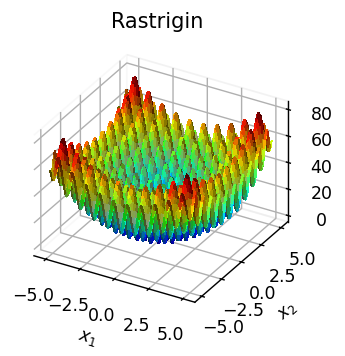

In [37]:
fun = bf.Rastrigin(2)
fun.plot(samples=100, resolution=125)
plt.show()

Agora vamos plotar de outroa forma, gerando uma grade de pontos x,y, calculando o valor da função(z) para o respectivos pontos e plotando um gráfico 3d. Nesse método estamos fazendo a mesma coisa que fizemos anteriormente, de outra forma.

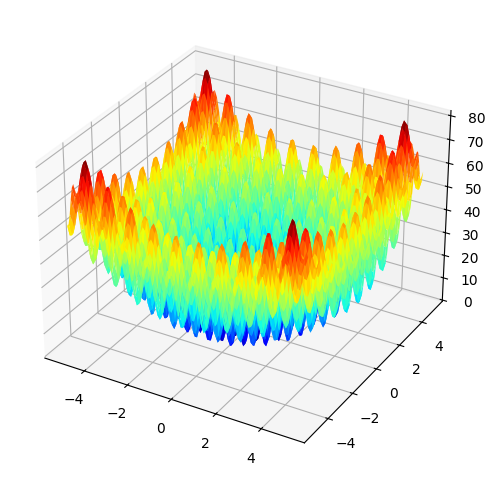

In [7]:
samples = 100

space_constraints = np.array(fun.get_search_range()).T

X, Y = np.meshgrid(np.linspace(*space_constraints[0], samples),
                   np.linspace(*space_constraints[1], samples))
Z = np.array([fun.get_function_value([x, y])
          for x, y in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, linewidth=0.5,
                antialiased=True, cmap=plt.cm.jet)
plt.show()

Agora vamos plotar outra função e fazer algumas modificações diretamente nela

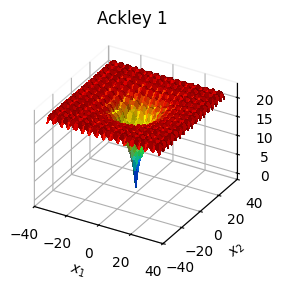

In [8]:
fun = bf.Ackley1(2)
fun.plot()
plt.show()

Aqui estamos alterando os limites inferiores e superiores de x,y na função[x, y ∈ {-1, 1}], isso restringe a região de busca onde a otimização pode ocorrer

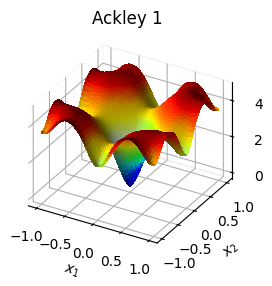

In [9]:
fun.set_search_range([-1.0, -1.0], [1.0, 1.0])
fun.plot()
plt.show()

Aqui temos alguns métodos interessantes de modificação.


| **Função** | **Transformação Matemática** | **Efeito Prático** | **Exemplo** |
|------------|------------------------------|----------------------|-------------|
| **`set_offset_function(c)`** | $ f'(x) = f(x) + c $ | **Desloca a função verticalmente** (soma um valor fixo). | Se $ f(x) = 3.0 $, com `set_offset_function(-2)`, o novo valor será $ 3.0 - 2 = 1.0 $. |
| **`set_scale_function(k)`** | $ f'(x) = k \cdot f(x) $ | **Amplia ou reduz os valores da função**, tornando a otimização mais difícil ou mais fácil. | Se $ f(x) = 3.0 $, com `set_scale_function(2)`, o novo valor será $ 3.0 \cdot 2 = 6.0 $. |
| **`set_noise_level(c)`** | $ f'(x) = f(x) + \text{ruído} $ | **Adiciona variação aleatória à saída da função**, simulando incertezas. | Se $ f(x) = 5.0 $, com `set_noise_level(1.0)`, o valor pode ser $ 5.0 \pm \text{um número aleatório entre -1 e 1} $. |
| **`set_offset_domain([a, b])`** | $ f'(x, y) = f(x - a, y - b) $ | **Move a função no espaço de entrada**, mudando a posição dos ótimos. | Se o mínimo global estava em $ (0,0) $, com `set_offset_domain([0.5, 0.5])`, ele agora estará em $ (0.5,0.5) $. |
| **`set_search_range([a_1, a_2], [b_1, b_2])`** | Define novos limites de busca para $ x, y $. | **Restringe o espaço de busca**, forçando o algoritmo a trabalhar em uma região menor. | Se antes $ x, y \in [-5, 5] $, com `set_search_range([-1, -1], [1, 1])`, agora $ x, y \in [-1, 1] $. |



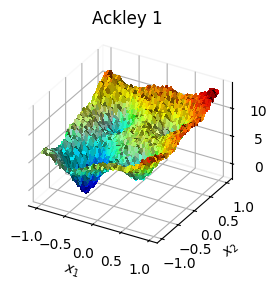

In [10]:
fun.set_offset_function(-2)
fun.set_scale_function(2)
fun.set_noise_level(1.0)
fun.set_offset_domain([0.5, 0.5])
fun.plot()
plt.show()

## 2. Módulo de população (customhys.population)
Nessa seção nós itemos ver o módulo de população, esse que é a base para os algoritmos de otimização que iremos implementar com o farmework.

Vamos começar importando o módulo e alguns útilitários que vamos utilizar para plotar

In [11]:
from customhys import  population as pp
fun = bf.Rastrigin(2)

Agora, nós iremos gerar a população baseado no espaço de busca do problema definido. Essa geração pode ser randomica(random) ou com os agentes começando nos vértices do espaço de busca(vertex).


### 📌 Diferença entre Inicialização `'vertex'` e `'random'`

| **Agente** | **Posição (Vertex)** | **Posição (Random)** |
|------------|----------------------|----------------------|
| Agente 1   | `[-5.0, -5.0]`       | `[-3.2, 1.7]`       |
| Agente 2   | `[-5.0, 5.0]`        | `[4.1, -2.8]`       |
| Agente 3   | `[5.0, -5.0]`        | `[0.9, 3.6]`        |
| Agente 4   | `[5.0, 5.0]`         | `[-1.4, -4.5]`      |
| Agente 5   | `[-4.0, -4.0]`       | `[3.3, -1.1]`       |
| Agente 6   | `[-4.0, 4.0]`        | `[-2.7, 4.9]`       |
| Agente 7   | `[4.0, -4.0]`        | `[1.8, -3.4]`       |
| Agente 8   | `[4.0, 4.0]`         | `[4.5, 2.2]`        |

### 🔹 **Explicação**
- **`'vertex'`** → Os agentes são inicializados nos **vértices do espaço de busca**, formando uma grade estruturada.
- **`'random'`** → Os agentes são inicializados **em posições aleatórias dentro do espaço de busca**, garantindo mais diversidade.

💡 **Quando usar cada um?**
- **Vertex:** Melhor para **cobrir as extremidades do espaço de busca rapidamente**.
- **Random:** Melhor para **exploração inicial mais diversificada**.


In [39]:
pop_vertex = pp.Population(fun.get_search_range(), num_agents=10)
pop_vertex.initialise_positions('vertex')

pop_random = pp.Population(fun.get_search_range(), num_agents=10)
pop_random.initialise_positions('random')

pop_sobol = pp.Population(fun.get_search_range(), num_agents=10)
pop_sobol.initialise_positions('sobol')



Perceba a diferença entre as posições internas e externa da população, isso ocorre pois o framework customhys pode normalizar os valores para valores menores, para poder facilitar seus calculos. As posições internas siginficam os valores para o framework, e as posições externas os valores de acordo com o problema.

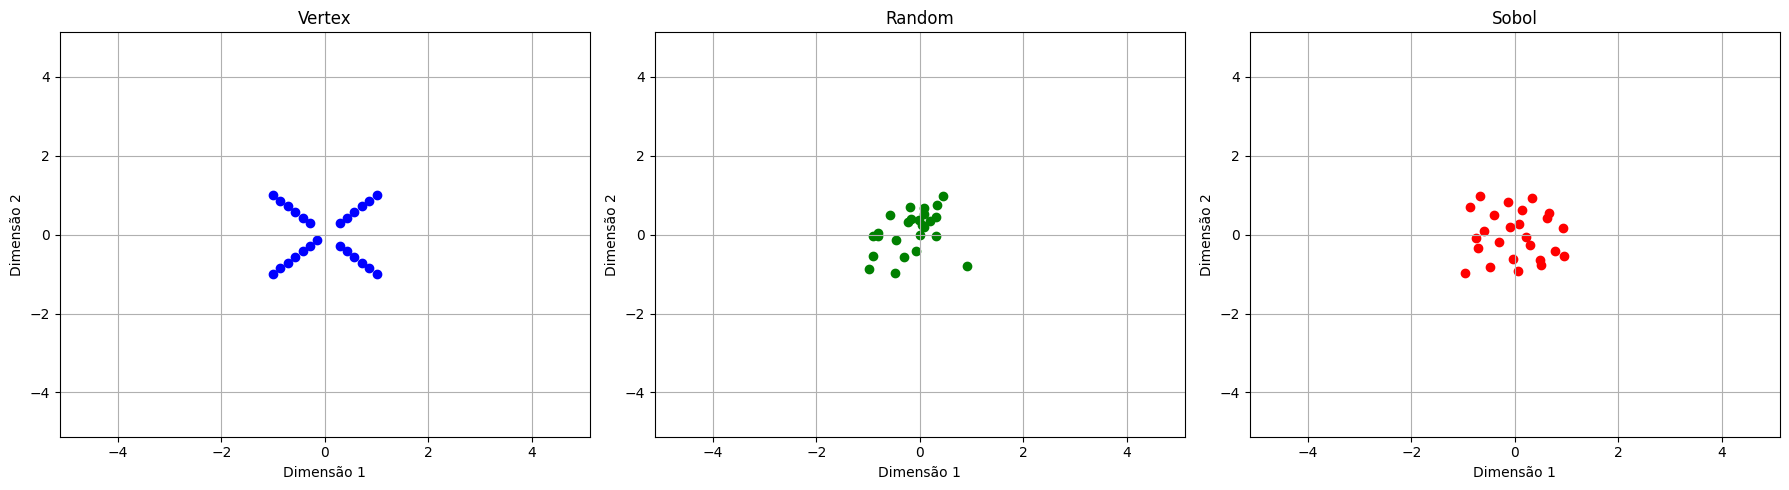

In [41]:
# Pega os limites do problema
lower, upper = fun.get_search_range()

plt.figure(figsize=(18, 5))

# Vertex
plt.subplot(1, 3, 1)
plt.scatter(pop_vertex.positions[:, 0], pop_vertex.positions[:, 1], c='blue')
plt.title("Vertex")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.xlim(lower[0], upper[0])
plt.ylim(lower[1], upper[1])
plt.grid(True)

# Random
plt.subplot(1, 3, 2)
plt.scatter(pop_random.positions[:, 0], pop_random.positions[:, 1], c='green')
plt.title("Random")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.xlim(lower[0], upper[0])
plt.ylim(lower[1], upper[1])
plt.grid(True)

# Sobol
plt.subplot(1, 3, 3)
plt.scatter(pop_sobol.positions[:, 0], pop_sobol.positions[:, 1], c='red')
plt.title("Sobol")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.xlim(lower[0], upper[0])
plt.ylim(lower[1], upper[1])
plt.grid(True)

plt.tight_layout()
plt.show()

In [35]:
print("Vertex Internal Positions: ", pop_vertex.positions)
print("Vertex External Positions: ", pop_vertex.get_positions())

print("Random Internal Positions: ", pop_random.positions)
print("Random External Positions: ", pop_random.get_positions())

print("Sobol Internal Positions: ", pop_sobol.positions)
print("Sobol External Positions: ", pop_sobol.get_positions())


Vertex Internal Positions:  [[-1.         -1.        ]
 [-1.          1.        ]
 [ 1.         -1.        ]
 [ 1.          1.        ]
 [-0.92307692 -0.92307692]
 [-0.92307692  0.92307692]
 [ 0.92307692 -0.92307692]
 [ 0.92307692  0.92307692]
 [-0.84615385 -0.84615385]
 [-0.84615385  0.84615385]
 [ 0.84615385 -0.84615385]
 [ 0.84615385  0.84615385]
 [-0.76923077 -0.76923077]
 [-0.76923077  0.76923077]
 [ 0.76923077 -0.76923077]
 [ 0.76923077  0.76923077]
 [-0.69230769 -0.69230769]
 [-0.69230769  0.69230769]
 [ 0.69230769 -0.69230769]
 [ 0.69230769  0.69230769]
 [-0.61538462 -0.61538462]
 [-0.61538462  0.61538462]
 [ 0.61538462 -0.61538462]
 [ 0.61538462  0.61538462]
 [-0.53846154 -0.53846154]
 [-0.53846154  0.53846154]
 [ 0.53846154 -0.53846154]
 [ 0.53846154  0.53846154]
 [-0.46153846 -0.46153846]
 [-0.46153846  0.46153846]
 [ 0.46153846 -0.46153846]
 [ 0.46153846  0.46153846]
 [-0.38461538 -0.38461538]
 [-0.38461538  0.38461538]
 [ 0.38461538 -0.38461538]
 [ 0.38461538  0.38461538]


Já que temos que temos que avaliar a qualidade de cada posição para um determinado problema, temos uma função de avaliação.

In [15]:
pop.evaluate_fitness(lambda x: fun.get_function_value(x))
print(pop.fitness)  

[57.84942745 57.84942745 57.84942745 57.84942745 79.98309403 79.98309403
 79.98309403 79.98309403 38.7746641  38.7746641  38.7746641  38.7746641
 34.29966011 34.29966011 34.29966011 34.29966011 51.70272972 51.70272972
 51.70272972 51.70272972  9.8466664   9.8466664   9.8466664   9.8466664
 27.02442629 27.02442629 27.02442629 27.02442629 33.56767979 33.56767979]


vamos ver as posições iniciais no espaço de busca

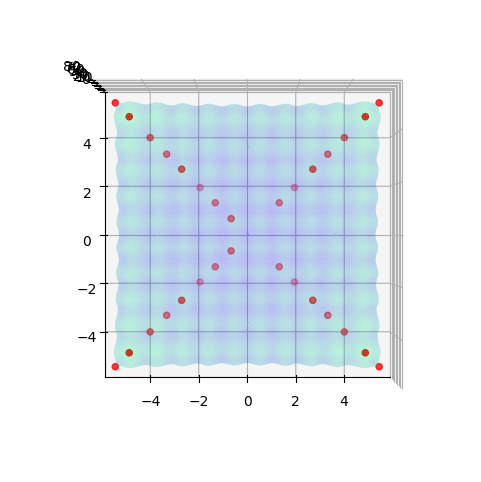

In [16]:
def show_positions(azim=-90, elev=90):
    positions = np.array(pop.get_positions())
    fitness = pop.fitness

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(projection='3d', )
    ax.plot_surface(X, Y, Z, rstride=1, cstride=1, linewidth=0.5,
                    antialiased=True, cmap=plt.cm.winter, alpha=0.25)
    ax.scatter(positions[:,0], positions[:,1], pop.fitness,
               marker='o', color='r')
    ax.view_init(elev, azim)
    plt.show()

show_positions()

Uma importante parte do módulo de populção é atualizar particulamente cada posição, para poder guardar informações históricas(ou não), para isso usamos alguns operadores.

Para isso a função update usa dois parâmetros principais, level e selector, o level define qual o nível de atualização será feito na população e o selector define e estratégia que será usada para atualizar as posições.

### 📌 Tabela Resumo - Diferença entre `level` e `selector`

| **Parâmetro** | **Opção** | **Descrição** | **Quando Usar?** |
|--------------|----------|--------------|------------------|
| `level` | `'population'` | Atualiza **toda a população**. | Quando queremos atualizar todas as posições. |
| `level` | `'particular'` | Atualiza as **melhores posições individuais** dos agentes. | Quando cada agente precisa lembrar seu melhor desempenho. |
| `level` | `'global'` | Atualiza a **melhor solução global** encontrada. | Quando queremos salvar a melhor solução global. |
| `selector` | `'greedy'` | Escolhe **sempre a melhor posição possível**. | Quando queremos convergir rapidamente. |
| `selector` | `'probabilistic'` | Escolhe **posições aleatoriamente** com base em probabilidade. | Quando queremos diversidade na busca. |
| `selector` | `'metropolis'` | Aceita **posições piores às vezes**, baseado em Simulated Annealing. | Quando queremos evitar mínimos locais. |
| `selector` | `'all'` | Atualiza **todas as posições indiscriminadamente**. | Quando queremos resetar ou preparar a população. |
| `selector` | `'none'` | **Nenhuma atualização é feita**. | Quando queremos manter as posições inalteradas. |


In [17]:
pop.update_positions(level='population', selector='all')
pop.update_positions(level='particular', selector='all')
pop.update_positions(level='global', selector='greedy')

Now, let us see which is the best position among all.

In [18]:
print(pop.get_state())

x_best = [-1.92 -1.92], f_best = 9.846666399122741


## 3. Módulo de operadores (customhys.operators)
Nessa seção iremos ver um dos mais importantes módulos, o módulo de operadores, eles são fundamentais na construçãod dos algoritmos de otimização dentro do Custhomhys, sendo responsável por modificar a populção e assim gerando novas soluções.

In [19]:
from customhys import operators as op

### 📌 Operadores (`Perturbadores`) - CustomHyS

Os **operadores** são responsáveis por modificar as soluções dentro da população. Eles perturbam as posições dos agentes para explorar novas possibilidades e melhorar a otimização.

#### **🔹 Como os operadores funcionam?**
1️⃣ Pegam as posições atuais da população.  
2️⃣ Aplicam um **método de perturbação** para gerar novas soluções.  
3️⃣ Introduzem **variabilidade e diversidade**, ajudando o algoritmo a **explorar melhor o espaço de busca**.  

---

#### **📌 Tipos de Operadores Disponíveis**
| **Operador** | **Descrição** |
|-------------|--------------|
| `local_random_walk` | Move os agentes com um pequeno passo aleatório em torno da posição atual, útil para refinamento local. |
| `random_search` | Gera novos candidatos aleatoriamente em todo o espaço de busca, promovendo exploração ampla. |
| `random_sample` | Seleciona um subconjunto aleatório de candidatos como novas posições da população. |
| `random_flight` | Move os agentes de forma aleatória com passos longos, simulando voos de Lévy(Padrão matemático). |
| `differential_mutation` | Aplica a mutação diferencial, gerando novos agentes a partir da combinação de outros indivíduos da população. |
| `firefly_dynamic` | Simula o comportamento de vaga-lumes, onde soluções melhores atraem outras soluções. |
| `swarm_dynamic` | Baseado na otimização por enxame de partículas (PSO), ajustando posições de acordo com líderes do grupo. |
| `gravitational_search` | Simula um sistema gravitacional, onde soluções mais fortes (melhores) atraem soluções mais fracas. |
| `central_force_dynamic` | Aplica uma **força central nos agentes**, atraindo-os para um ponto médio comum. |
| `spiral_dynamic` | Move os agentes em padrões espirais ao redor de pontos promissores, permitindo exploração e refinamento. |
| `genetic_mutation` | Aplica **mutação genética** nas soluções, alterando alguns valores aleatoriamente. |
| `genetic_crossover` | Realiza o **crossover genético**, combinando partes de diferentes soluções para criar novas combinações. |

---

#### **📌 Como visualizar os operadores disponíveis?**
Podemos listar todos os operadores suportados pelo **CustomHyS** com o seguinte código:

In [20]:
print('Perturbadores: ', op.__all__)

Perturbadores:  ['local_random_walk', 'random_search', 'random_sample', 'random_flight', 'differential_mutation', 'firefly_dynamic', 'swarm_dynamic', 'gravitational_search', 'central_force_dynamic', 'spiral_dynamic', 'genetic_mutation', 'genetic_crossover']


### 📌 Seletores - CustomHyS

Os **seletores** definem **como a população escolhe quais soluções continuarão** para a próxima iteração. Eles atuam após os operadores para selecionar as melhores soluções.

---

#### **🔹 Como os seletores funcionam?**
1️⃣ A população **aplica operadores e gera novas soluções**.  
2️⃣ Os seletores **decidem quais soluções serão mantidas** na população.  
3️⃣ Dependendo do seletor usado, a população pode ser mais **exploratória (diversidade)** ou mais **exploitativa (foco nas melhores soluções)**.  

---

#### **📌 Tipos de Seletores Disponíveis**
| **Seletor** | **Descrição** |
|------------|--------------|
| `'all'` | Mantém **todas as soluções** da população sem critério de escolha. Útil para estratégias que não precisam de seleção rígida. |
| `'greedy'` | Sempre escolhe a **melhor posição possível**, garantindo que a população siga um caminho de melhoria contínua. |
| `'metropolis'` | Baseado no algoritmo de Simulated Annealing, **aceita soluções piores ocasionalmente** para evitar mínimos locais. |
| `'probabilistic'` | Seleciona soluções **de forma aleatória**, permitindo maior diversidade na população. |

---

In [21]:
print('Selectores: ', op.__selectors__)

Selectores:  ['all', 'greedy', 'metropolis', 'probabilistic']


Agora, vamos ver a coleção operadores que é padrão do framework

In [20]:
import pkgutil
data = pkgutil.get_data("customhys", "collections/default.txt")

for i, x in enumerate(data.decode().split("\n")[:-1]):
    print(i, x, sep=" :: ")

0 :: ('random_search', {'scale': 1.0, 'distribution': 'uniform'}, 'greedy')
1 :: ('central_force_dynamic', {'gravity': 0.001, 'alpha': 0.01, 'beta': 1.5, 'dt': 1.0}, 'all')
2 :: ('central_force_dynamic', {'gravity': 0.001, 'alpha': 0.01, 'beta': 1.5, 'dt': 1.0}, 'greedy')
3 :: ('central_force_dynamic', {'gravity': 0.001, 'alpha': 0.01, 'beta': 1.5, 'dt': 1.0}, 'metropolis')
4 :: ('central_force_dynamic', {'gravity': 0.001, 'alpha': 0.01, 'beta': 1.5, 'dt': 1.0}, 'probabilistic')
5 :: ('differential_mutation', {'expression': 'rand', 'num_rands': 1, 'factor': 1.0}, 'all')
6 :: ('differential_mutation', {'expression': 'rand', 'num_rands': 1, 'factor': 1.0}, 'greedy')
7 :: ('differential_mutation', {'expression': 'rand', 'num_rands': 1, 'factor': 1.0}, 'metropolis')
8 :: ('differential_mutation', {'expression': 'rand', 'num_rands': 1, 'factor': 1.0}, 'probabilistic')
9 :: ('differential_mutation', {'expression': 'best', 'num_rands': 1, 'factor': 1.0}, 'all')
10 :: ('differential_mutation',

In [21]:
dop = [eval(x) for x in data.decode().split("\n")[:-1]]
pd.DataFrame(dop, columns=['Perturbator', 'Parameters', 'Selector'])

,Perturbator,Parameters,Selector
0,random_search,"{'scale': 1.0, 'distribution': 'uniform'}",greedy
1,central_force_dynamic,"{'gravity': 0.001, 'alpha': 0.01, 'beta': 1.5,...",all
2,central_force_dynamic,"{'gravity': 0.001, 'alpha': 0.01, 'beta': 1.5,...",greedy
3,central_force_dynamic,"{'gravity': 0.001, 'alpha': 0.01, 'beta': 1.5,...",metropolis
4,central_force_dynamic,"{'gravity': 0.001, 'alpha': 0.01, 'beta': 1.5,...",probabilistic
...,...,...,...
200,swarm_dynamic,"{'factor': 1.0, 'self_conf': 2.54, 'swarm_conf...",probabilistic
201,swarm_dynamic,"{'factor': 1.0, 'self_conf': 2.54, 'swarm_conf...",all
202,swarm_dynamic,"{'factor': 1.0, 'self_conf': 2.54, 'swarm_conf...",greedy
203,swarm_dynamic,"{'factor': 1.0, 'self_conf': 2.54, 'swarm_conf...",metropolis


Você pode gerar uma coleção automáticamente salvando em formato de texto, podendo ser acessivel e editavel por um editor de texto qualquer 

In [22]:
op_task = op.obtain_operators(num_vals=5)
print(op_task.__len__(), op_task)

15 [('random_search', {'scale': [1.0], 'distribution': ['uniform']}, ['greedy']), ('central_force_dynamic', {'gravity': [0.0, 0.0025, 0.005, 0.0075, 0.01], 'alpha': [0.0, 0.0025, 0.005, 0.0075, 0.01], 'beta': [1.0, 1.25, 1.5, 1.75, 2.0], 'dt': [0.0, 0.5, 1.0, 1.5, 2.0]}, ['all', 'greedy', 'metropolis', 'probabilistic']), ('differential_crossover', {'crossover_rate': [0.0, 0.25, 0.5, 0.75, 1.0], 'version': ['binomial', 'exponential']}, ['all', 'greedy', 'metropolis', 'probabilistic']), ('differential_mutation', {'expression': ['rand', 'best', 'current', 'current-to-best', 'rand-to-best', 'rand-to-best-and-current'], 'num_rands': [1, 2, 3], 'factor': [0.0, 0.625, 1.25, 1.875, 2.5]}, ['all', 'greedy', 'metropolis', 'probabilistic']), ('firefly_dynamic', {'distribution': ['uniform', 'gaussian', 'levy'], 'alpha': [0.0, 0.125, 0.25, 0.375, 0.5], 'beta': [0.01, 0.2575, 0.505, 0.7525, 1.0], 'gamma': [1.0, 250.75, 500.5, 750.25, 1000.0]}, ['all', 'greedy', 'metropolis', 'probabilistic']), ('gen

In [23]:
op.build_operators(heuristics=op_task, file_name='op_tutorial')

random_search: parameters=2, combinations:1
central_force_dynamic: parameters=4, combinations:625
differential_crossover: parameters=2, combinations:10
differential_mutation: parameters=3, combinations:90
firefly_dynamic: parameters=4, combinations:375
genetic_crossover: parameters=3, combinations:225
genetic_mutation: parameters=4, combinations:375
gravitational_search: parameters=2, combinations:25
random_flight: parameters=3, combinations:25
random_flight: parameters=2, combinations:10
local_random_walk: parameters=3, combinations:75
random_sample: parameters=0, combinations:4
random_search: parameters=2, combinations:15
spiral_dynamic: parameters=3, combinations:125
swarm_dynamic: parameters=5, combinations:750
----------------------------------------------------
TOTAL: families=15, operators=10917


In [24]:
with open("collections/op_tutorial.txt") as file:
    auto_operators = file.read()

print(f"Collection size: {auto_operators.__len__()}")
np.random.choice(auto_operators.split('\n'), 5)

Collection size: 1268903


array(["('swarm_dynamic', {'factor': 0.2575, 'self_conf': 0.01, 'swarm_conf': 4.99, 'version': 'constriction', 'distribution': 'gaussian'}, 'all')",
       "('central_force_dynamic', {'gravity': 0.0025, 'alpha': 0.01, 'beta': 1.75, 'dt': 1.5}, 'metropolis')",
       "('random_search', {'scale': 0.7525, 'distribution': 'levy'}, 'metropolis')",
       "('central_force_dynamic', {'gravity': 0.005, 'alpha': 0.0075, 'beta': 1.75, 'dt': 0.0}, 'greedy')",
       "('firefly_dynamic', {'distribution': 'uniform', 'alpha': 0.0, 'beta': 0.505, 'gamma': 1000.0}, 'greedy')"],
      dtype='<U176')

A coleção pode ser usada seguindo esses passos

In [25]:
print(dop[1])

op_to_test = op.process_operators([dop[1]])
print(op_to_test)

op_to_exect = "op.{}(pop,{}".format(*op_to_test[0][0].split('('))
print(op_to_exect)

('central_force_dynamic', {'gravity': 0.001, 'alpha': 0.01, 'beta': 1.5, 'dt': 1.0}, 'all')
--- LOG: Verificando simple_heuristics ---
Total de operadores recebidos: 1
Operador 0: ('central_force_dynamic', {'gravity': 0.001, 'alpha': 0.01, 'beta': 1.5, 'dt': 1.0}, 'all')
--- LOG: process_operators finalizado com sucesso ---
(['central_force_dynamic(gravity=0.001,alpha=0.01,beta=1.5,dt=1.0)'], ['all'])
op.central_force_dynamic(pop,gravity=0.001,alpha=0.01,beta=1.5,dt=1.0)


Iteration: 0 :: x_best = [ 1.92763838 -0.9634575 ], f_best = 5.922374990489034


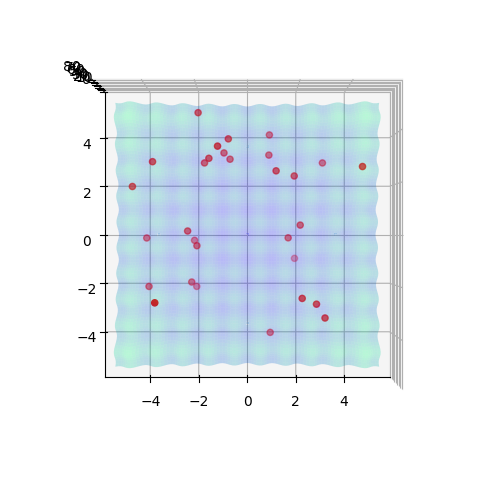

Iteration: 100 :: x_best = [0.98765533 0.96532067], f_best = 2.1738297410908345


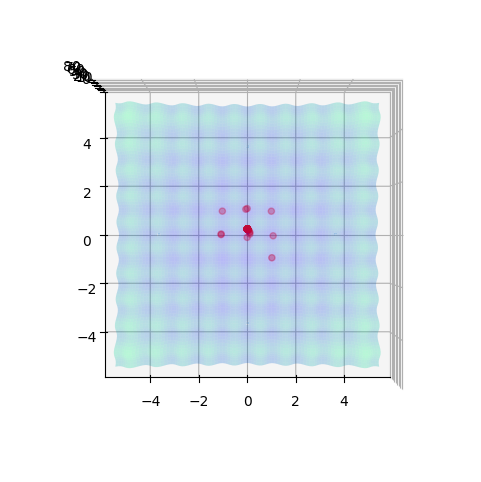

Iteration: 200 :: x_best = [0.98765533 0.96532067], f_best = 2.1738297410908345


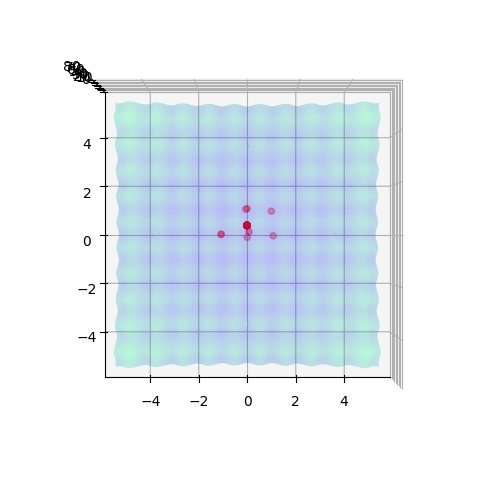

Iteration: 300 :: x_best = [-1.0724059   0.00579022], f_best = 2.17382974108995


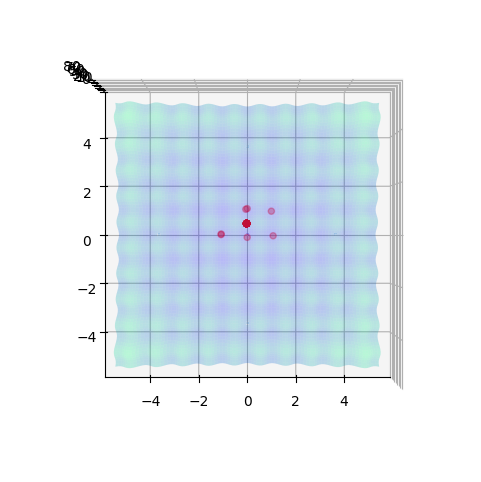

Iteration: 400 :: x_best = [ 1.06009218 -0.04186124], f_best = 2.1738297410885608


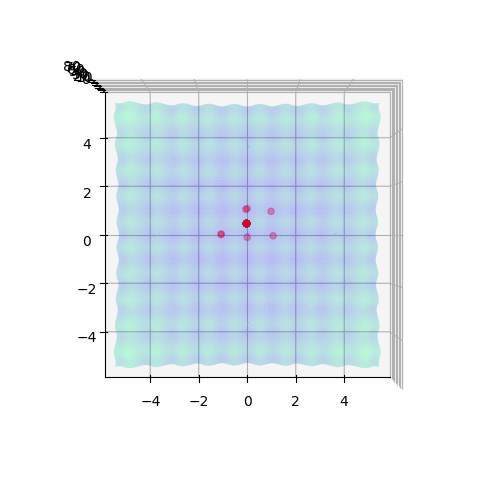

Iteration: 500 :: x_best = [-0.00231111  1.0725936 ], f_best = 2.1738297410871255


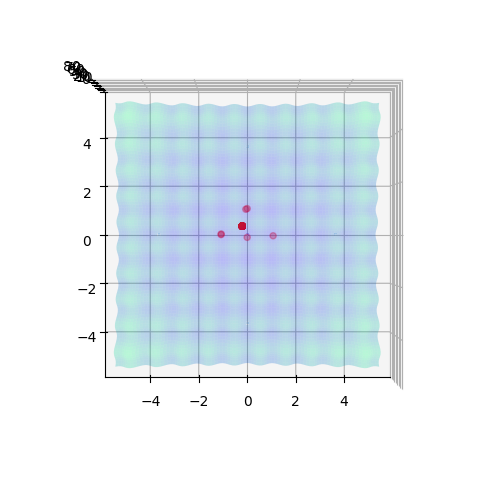

Iteration: 600 :: x_best = [-1.0724059   0.00579022], f_best = 2.1738297410861556


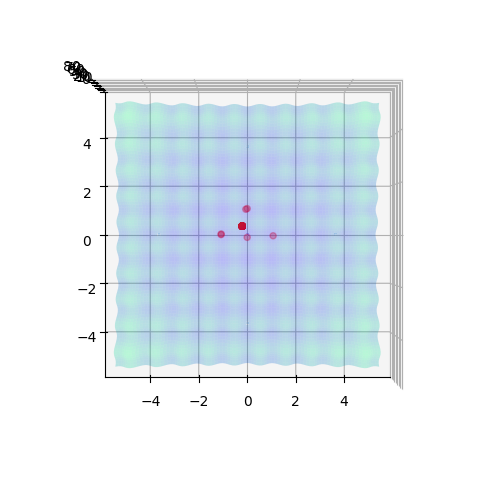

Iteration: 700 :: x_best = [-0.00231111  1.0725936 ], f_best = 2.173829741084969


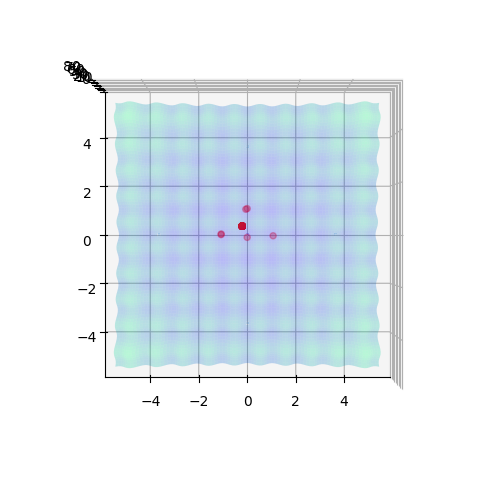

Iteration: 800 :: x_best = [-0.00231111  1.0725936 ], f_best = 2.173829741084745


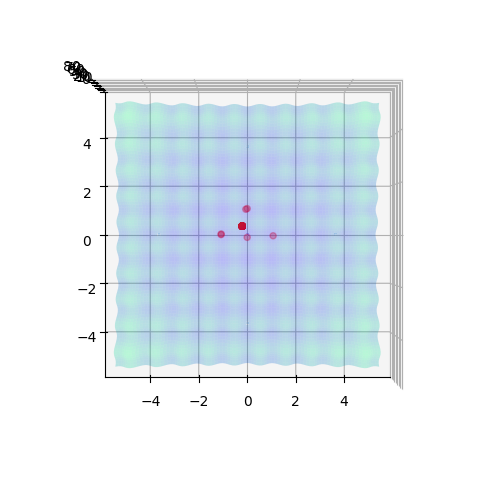

Iteration: 900 :: x_best = [-0.00231111  1.0725936 ], f_best = 2.173829741084745


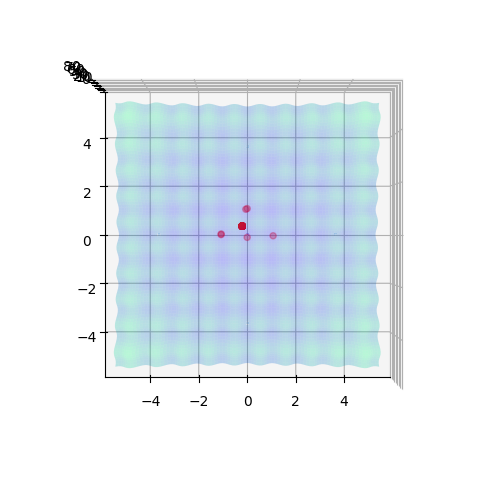

In [26]:
# Initial population
pop.initialise_positions('random')

# Evaluate the initial positions
pop.evaluate_fitness(lambda x: fun.get_function_value(x))

# Update the positions and fitness
pop.update_positions(level='population', selector='all')
pop.update_positions(level='global', selector='greedy')

# Save the initial state
history = [pop.fitness.copy()]

for iteration in range(1000):
    # Apply the perturbation heuristic
    # exec(op_to_exect)
    op.central_force_dynamic(pop, alpha=0.9, beta=0.45)
    
    # Evaluate the new positions
    pop.evaluate_fitness(lambda x: fun.get_function_value(x))

    # Choose random selectors (alpha version)
    selector = list(np.random.choice(['direct', 'greedy', 'probabilistic'], pop.num_agents))
    #selector = 'direct'

    # Update the positions
    pop.update_positions(level='population', selector=selector)
    pop.update_positions(level='global')   
    
    # Save the fitness
    history.append(pop.fitness.copy())

    if iteration % 100 == 0:
        print(f"Iteration: {iteration} ::", pop.get_state())
        show_positions()

Agora vamos plotar o histórico de valor do fitness


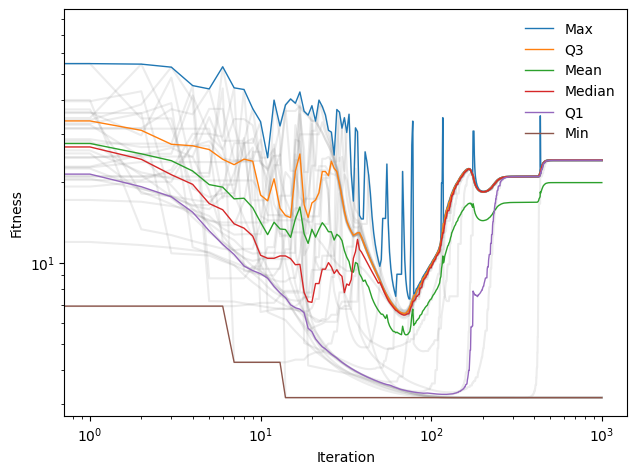

In [27]:
# Process the historical values
history = np.array(history) + 1

plt.figure()
# plot in gray scale to after plot some statistics above
plt.plot(history, color='gray', alpha=0.15)
plt.plot(history.max(axis=1), lw=1, label='Max')
plt.plot(np.quantile(history, 0.75, axis=1), lw=1, label='Q3')
plt.plot(history.mean(axis=1), lw=1, label='Mean')
plt.plot(np.median(history, axis=1), lw=1, label='Median')
plt.plot(np.quantile(history, 0.25, axis=1), lw=1, label='Q1')
plt.plot(history.min(axis=1), lw=1, label='Min')
#plt.plot(history.std(axis=1), lw=2, label='Std')

plt.legend(frameon=False)
plt.xlabel('Iteration'), plt.ylabel('Fitness')
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')
plt.show()



### 📌 Tabela - Métricas do Gráfico de Fitness

| **Métrica** | **Significado** | **Interpretação no Gráfico** |
|------------|---------------|---------------------------|
| **Max (`history.max(axis=1)`)** | Maior valor de fitness em cada iteração. | Indica a **pior solução** da população em cada iteração. |
| **Q3 (`np.quantile(history, 0.75, axis=1)`)** | Terceiro quartil (Q3): 75% das soluções têm fitness abaixo desse valor. | Se o Q3 cair ao longo do tempo, significa que **a maioria das soluções está melhorando**. |
| **Mean (`history.mean(axis=1)`)** | Média do fitness da população em cada iteração. | Mostra a **tendência geral** de melhoria do algoritmo. |
| **Median (`np.median(history, axis=1)`)** | Valor central do fitness (50% dos valores estão acima e 50% abaixo). | Acompanha a **tendência central** da população, evitando a influência de outliers. |
| **Q1 (`np.quantile(history, 0.25, axis=1)`)** | Primeiro quartil (Q1): 25% das soluções têm fitness abaixo desse valor. | Se o Q1 cair, significa que **as melhores soluções da população estão melhorando**. |
| **Min (`history.min(axis=1)`)** | Menor valor de fitness em cada iteração. | Representa a **melhor solução encontrada até aquele momento**. |

## 4. Módulo de metaheuristica (customhys.metaheuristic)
Nessa seção, nós veremos como se usa esse módulo para construir metaheusríticas

Nessa parte iremos pegar um problema da função de benchmark e formatar para um formato aceito pelo customhys

In [28]:
from customhys import metaheuristic as mh
fun = bf.Rastrigin(3)
prob = fun.get_formatted_problem()

prob

{'function': <function customhys.benchmark_func.BasicProblem.get_formatted_problem.<locals>.<lambda>(x)>,
 'boundaries': (array([-5.12, -5.12, -5.12]), array([5.12, 5.12, 5.12])),
 'is_constrained': True,
 'features': '110',
 'func_name': 'Rastrigin',
 'dimensions': 3}

A tabela abaixo detalha os operadores e seus respectivos parâmetros utilizados na heurística.

| **Elemento** | **Explicação** |
|-------------|--------------|
| **`differential_mutation`** | Aplica mutação diferencial baseada em indivíduos aleatórios da população. |
| **Parâmetro: `expression='current-to-best'`** | Usa a estratégia **"current-to-best"**, onde cada solução é mutada em direção à melhor solução encontrada. |
| **Parâmetro: `num_rands=2`** | Usa **dois indivíduos aleatórios** para calcular o vetor de mutação. |
| **Parâmetro: `factor=1.0`** | Define a **intensidade da mutação** (quanto os indivíduos se movem em direção a melhores soluções). |
| **Seletor: `greedy`** | Apenas **mantém a melhor solução** após a mutação. |
| **`differential_crossover`** | Combina indivíduos usando crossover diferencial. |
| **Parâmetro: `crossover_rate=0.2`** | Define a probabilidade de troca de genes entre indivíduos. |
| **Parâmetro: `version='binomial'`** | Utiliza a estratégia **binomial** para crossover. |

---

In [29]:
heur = [( # Search operator 1
    'differential_mutation',  # Perturbator
    {  # Parameters
        'expression': 'current-to-best',
        'num_rands': 2,
        'factor': 1.0},
    'greedy'  # Selector
), (  # Search operator 2
    'differential_crossover',  # Perturbator
    {  # Parameters
        'crossover_rate': 0.2,
        'version': 'binomial'
    },
    'greedy'  # Selector
)]

met = mh.Metaheuristic(prob, heur, num_iterations=1000)
met.verbose = True
met.run()
print('x_best = {}, f_best = {}'.format(*met.get_solution()))

--- LOG: Iniciando Metaheuristic ---
--- LOG: Parâmetros recebidos ---
Num_agents: 30, Num_iterations: 1000, Initial_scheme: random
Verbose: False
--- LOG: Criando população ---
--- LOG: Verificando search_operators (total: 2) ---
--- LOG: Estrutura de search_operators ---
Operador 0: ('differential_mutation', {'expression': 'current-to-best', 'num_rands': 2, 'factor': 1.0}, 'greedy')
Operador 1: ('differential_crossover', {'crossover_rate': 0.2, 'version': 'binomial'}, 'greedy')
--- LOG: Verificando simple_heuristics ---
Total de operadores recebidos: 2
Operador 0: ('differential_mutation', {'expression': 'current-to-best', 'num_rands': 2, 'factor': 1.0}, 'greedy')
Operador 1: ('differential_crossover', {'crossover_rate': 0.2, 'version': 'binomial'}, 'greedy')
--- LOG: process_operators finalizado com sucesso ---
--- LOG: process_operators executado com sucesso ---
--- LOG: Número máximo de iterações definido ---
--- LOG: Número de dimensões: 3 ---
--- LOG: Número de agentes: 30 ---
-

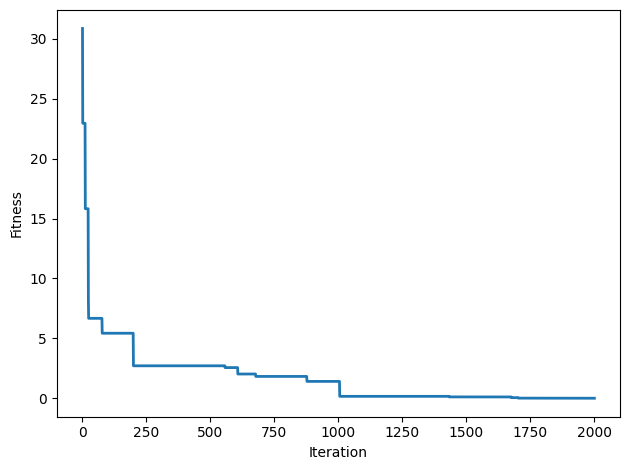

In [30]:
hist_values = met.historical

plt.figure()
plt.plot(hist_values['fitness'], lw=2)
plt.xlabel('Iteration'), plt.ylabel('Fitness')
plt.tight_layout()
plt.show()
# plt.savefig('ExFitness.svg')

O gráfico acima mostra a evolução do fitness ao decorrer das interações

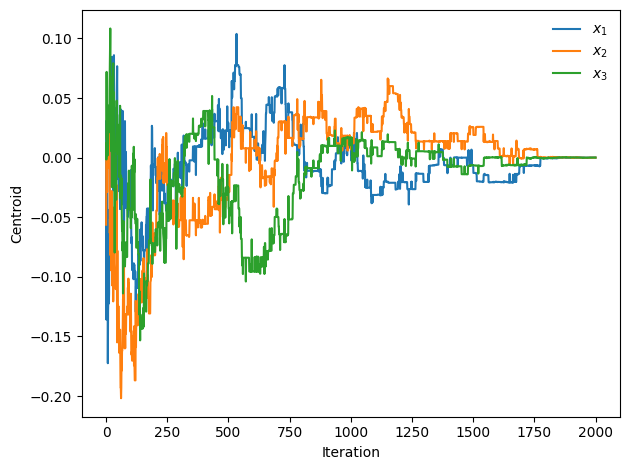

In [31]:
plt.figure()
plt.plot(hist_values['centroid'])
plt.xlabel(r'Iteration'), plt.ylabel(r'Centroid')
plt.legend([r'$x_1$', r'$x_2$', r'$x_3$'], frameon=False)
plt.tight_layout()
plt.show()
# plt.savefig('ExCentroid.svg')

### 📌 Evolução do Centróide

O gráfico acima mostra a **evolução do centróide** durante as iterações.

---

#### **📌 O que é o Centróide?**
📌 O **centróide** representa a posição média das soluções na população a cada iteração.  
📌 Ele indica **para onde a população está convergindo** durante a otimização.

---

#### **📌 O que a evolução do centróide significa?**
| **Comportamento do Centróide** | **Interpretação** |
|-------------------------------|------------------|
| **Centróide se estabilizando** | A população está **convergindo para uma solução única**, sugerindo que o algoritmo encontrou um ótimo local. |
| **Centróide mudando constantemente** | A população ainda está **explorando o espaço de busca**, possivelmente evitando mínimos locais. |
| **Centróide oscilando em pequenas variações** | Pode indicar **exploração refinada** em torno da melhor solução encontrada. |

💡 **Se o centróide para de mudar, o algoritmo pode ter convergido completamente para um ótimo local.**  
💡 **Se continua mudando, o algoritmo ainda está explorando novas soluções.**

---

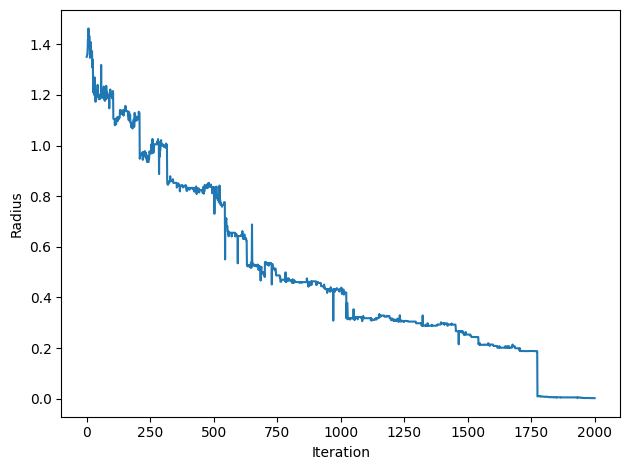

In [32]:
plt.figure()
plt.plot(hist_values['radius'])
plt.xlabel(r'Iteration'), plt.ylabel(r'Radius')
plt.tight_layout()
plt.show()
# plt.savefig('E|xRadius.svg')

### 📌 Evolução do Raio

O gráfico acima mostra a **evolução do raio** durante as iterações.

---

#### **📌 O que é o Raio?**
📌 O **raio** representa a **dispersão da população** no espaço de busca.  
📌 Ele mede **o quão espalhadas estão as soluções** ao longo das iterações.  

---

#### **📌 O que a evolução do raio significa?**
| **Comportamento do Raio** | **Interpretação** |
|-------------------------|------------------|
| **Raio alto e estável** | A população ainda está **explorando diferentes regiões** do espaço de busca. |
| **Raio diminuindo gradualmente** | O algoritmo está **convergindo**, concentrando as soluções em uma região específica. |
| **Raio muito pequeno** | A população está **altamente concentrada** em torno de uma solução, indicando possível convergência. |
| **Raio oscilando** | Pode indicar **exploração contínua**, útil para evitar mínimos locais. |

💡 **Se o raio diminui com o tempo, significa que as soluções estão se agrupando em torno de uma resposta ótima.**  
💡 **Se o raio permanece grande, a população ainda está explorando diferentes áreas do espaço de busca.**  

---

Vamos fazer o mesmo com outro problema e outra metaheuristica

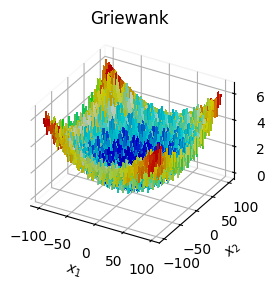

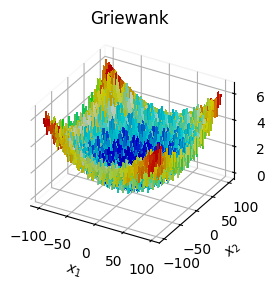

In [33]:
# This the minimisation problem to solve
fun = bf.Griewank(6)
prob = fun.get_formatted_problem()
fun.plot()

In [34]:
# This will be the metaheuristic
heu_seq = [
    ('random_search', {'scale': 1.0, 'distribution': 'uniform'}, 'greedy'),
    ('spiral_dynamic', {'radius': 0.9, 'angle': 33.5, 'sigma': 0.1}, 'all'),
    ('gravitational_search', {'gravity': 0.5, 'alpha': 0.2}, 'metropolis')
    ]
met = mh.Metaheuristic(prob, heur, num_iterations=5000, num_agents=100)
met.verbose = False
met.run()
print('x_best = {}, f_best = {}'.format(*met.get_solution()))

--- LOG: Iniciando Metaheuristic ---
--- LOG: Parâmetros recebidos ---
Num_agents: 100, Num_iterations: 5000, Initial_scheme: random
Verbose: False
--- LOG: Criando população ---
--- LOG: Verificando search_operators (total: 2) ---
--- LOG: Estrutura de search_operators ---
Operador 0: ('differential_mutation', {'expression': 'current-to-best', 'num_rands': 2, 'factor': 1.0}, 'greedy')
Operador 1: ('differential_crossover', {'crossover_rate': 0.2, 'version': 'binomial'}, 'greedy')
--- LOG: Verificando simple_heuristics ---
Total de operadores recebidos: 2
Operador 0: ('differential_mutation', {'expression': 'current-to-best', 'num_rands': 2, 'factor': 1.0}, 'greedy')
Operador 1: ('differential_crossover', {'crossover_rate': 0.2, 'version': 'binomial'}, 'greedy')
--- LOG: process_operators finalizado com sucesso ---
--- LOG: process_operators executado com sucesso ---
--- LOG: Número máximo de iterações definido ---
--- LOG: Número de dimensões: 6 ---
--- LOG: Número de agentes: 100 ---

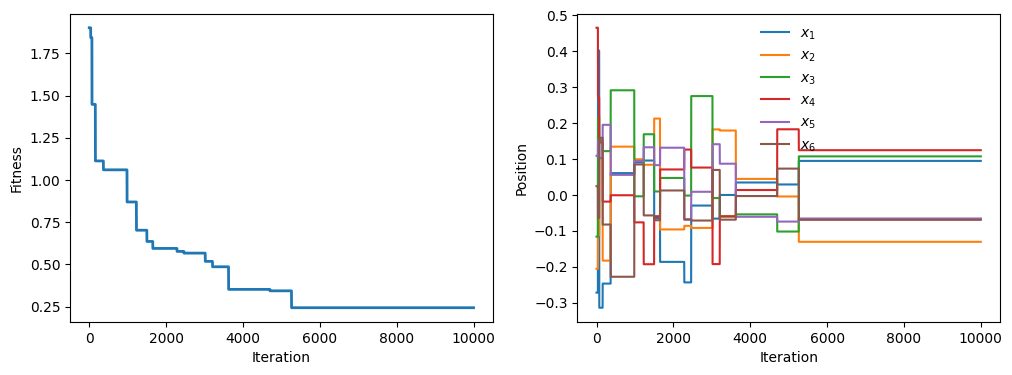

In [35]:
hist_values = met.historical

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(hist_values['fitness'], lw=2)
axs[0].set_xlabel('Iteration'), axs[0].set_ylabel('Fitness')

axs[1].plot(hist_values['position'])
axs[1].set_xlabel(r'Iteration'), axs[1].set_ylabel(r'Position')
axs[1].legend([f"$x_{ii+1}$" for ii in range(6)], frameon=False)

plt.show()

In [36]:
# Initialise the fitness register
fitness = []
# Run the metaheuristic with the same problem 30 times
for rep in range(30):
    met = mh.Metaheuristic(prob, heur, num_iterations=30, num_agents=50)
    met.reset_historicals()
    met.verbose = False
    met.run()
    print('rep = {}, x_best = {}, f_best = {}'.format(rep+1, *met.get_solution()))
    
    fitness.append(met.historical['fitness'])

--- LOG: Iniciando Metaheuristic ---
--- LOG: Parâmetros recebidos ---
Num_agents: 50, Num_iterations: 30, Initial_scheme: random
Verbose: False
--- LOG: Criando população ---
--- LOG: Verificando search_operators (total: 2) ---
--- LOG: Estrutura de search_operators ---
Operador 0: ('differential_mutation', {'expression': 'current-to-best', 'num_rands': 2, 'factor': 1.0}, 'greedy')
Operador 1: ('differential_crossover', {'crossover_rate': 0.2, 'version': 'binomial'}, 'greedy')
--- LOG: Verificando simple_heuristics ---
Total de operadores recebidos: 2
Operador 0: ('differential_mutation', {'expression': 'current-to-best', 'num_rands': 2, 'factor': 1.0}, 'greedy')
Operador 1: ('differential_crossover', {'crossover_rate': 0.2, 'version': 'binomial'}, 'greedy')
--- LOG: process_operators finalizado com sucesso ---
--- LOG: process_operators executado com sucesso ---
--- LOG: Número máximo de iterações definido ---
--- LOG: Número de dimensões: 6 ---
--- LOG: Número de agentes: 50 ---
---

In [37]:
fitness

[[array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.4447428),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.16310731),
  array(2.163107

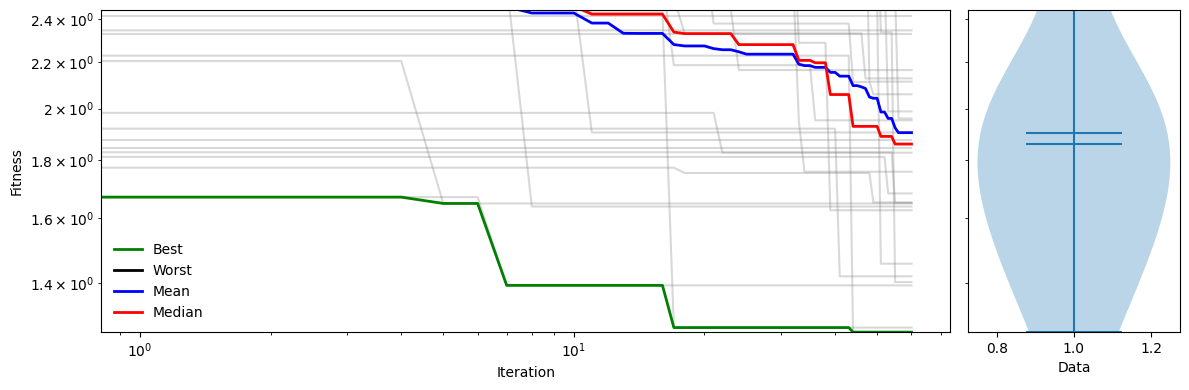

In [38]:
fitness_array = np.array(fitness).T
final_fitness = np.array([x[-1] for x in fitness_array.T])
best_fitness = np.min(fitness_array)
initial_fitness = max([x[0] for x in fitness_array])

# Now plot the fitness values
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey='row', gridspec_kw={'width_ratios': [0.8, 0.2]})
axs[0].plot(fitness_array, 'grey', alpha=0.3)

axs[0].plot(np.min(fitness_array, axis=1), 'g', lw=2, label='Best')
axs[0].plot(np.max(fitness_array, axis=1), 'k', lw=2, label='Worst')
axs[0].plot(np.mean(fitness_array, axis=1), 'b', lw=2, label='Mean')
axs[0].plot(np.median(fitness_array, axis=1), 'r', lw=2, label='Median')

axs[0].set_ylabel(r'Fitness')
axs[0].set_xlabel(r'Iteration')
axs[0].set_ylim([best_fitness, initial_fitness])

# Violin plot
axs[1].violinplot(final_fitness, showmeans=True, showmedians=True)
axs[1].set_xlabel(r'Data')

axs[0].legend(frameon=False)

axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[0].set_xscale('log')
plt.tight_layout()
plt.show()

## 5. Módulo de hyperheuristicas (customhys.hyperheuristic)

Essa seção é dedicada a utilizar o módulo para implementações de hyperheuristicas para encontrar a melhor combinação de metaheuristicas(ou apenas 1, não faz diferença) para um determinado problema.

In [39]:
parameters = dict(
    cardinality=3,  # Max. numb. of SOs in MHs, lvl:1
    cardinality_min=1,  # Min. numb. of SOs in MHs, lvl:1
    num_iterations=100,  # Iterations an MH performs, lvl:1
    num_agents=30,  # Agents in population,     lvl:1
    as_mh=True,  # HH sequence as a MH?,     lvl:2
    num_replicas=30,  # Replicas per each MH,     lvl:2
    num_steps=50,  # Trials per HH step,       lvl:2
    stagnation_percentage=0.37,  # Stagnation percentage,    lvl:2
    max_temperature=100,  # Initial temperature (SA), lvl:2
    min_temperature=1e-6,  # Min temperature (SA),     lvl:2
    cooling_rate=1e-3,  # Cooling rate (SA),        lvl:2
    temperature_scheme='fast',  # Temperature updating (SA),lvl:2
    acceptance_scheme='exponential',  # Acceptance mode,          lvl:2
    allow_weight_matrix=True,  # Weight matrix,            lvl:2
    trial_overflow=False,  # Trial overflow policy,    lvl:2
    learnt_dataset=None,  # If it is a learnt dataset related with the heuristic space
    repeat_operators=True,  # Allow repeating SOs inSeq,lvl:2
    verbose=True,  # Verbose process,          lvl:2
    learning_portion=0.37,  # Percent of seqs to learn  lvl:2
    solver='static')  # Indicate which solver use lvl:1

In [41]:
from customhys import hyperheuristic as hh

dime = 5
fun = bf.Griewank(dime)

cate = fun.get_features()
prob = fun.get_formatted_problem()

hyp = hh.Hyperheuristic(heuristic_space="default.txt",
                        problem=prob, parameters=parameters, file_label='Griewank-5D-Exp2')

best_sol, hist_curr, hist_best = hyp.solve()

--- LOG: Iniciando _solve_static ---
--- LOG: Gerando solução inicial ---
--- LOG: Entrando em _obtain_candidate_solution ---
Parâmetro recebido sol: None
Parâmetro action: None
Parâmetro operators_weights: None
Parâmetro top: None
--- LOG: Criando solução inicial ---
--- LOG: encoded_neighbour gerado: [148] ---
--- LOG: Solução inicial gerada: [148] ---
--- LOG: Avaliando solução inicial ---
--- LOG: Iniciando evaluate_candidate_solution ---
--- LOG: encoded_sequence recebido ---
Tipo: <class 'list'> | Conteúdo: [148]
--- LOG: encoded_sequence convertido para operadores ---
[('random_flight', {'scale': 1.0, 'distribution': 'gaussian'}, 'probabilistic')]
--- LOG: search_operators validado ---
[('random_flight', {'scale': 1.0, 'distribution': 'gaussian'}, 'probabilistic')]
--- LOG: Iniciando execuções da Metaheuristic ---
--- LOG: Rodada 1/30 ---
--- LOG: Iniciando Metaheuristic ---
--- LOG: Parâmetros recebidos ---
Num_agents: 30, Num_iterations: 100, Initial_scheme: random
Verbose: Fa

ValueError: too many values to unpack (expected 3)

In [113]:
# print("Performance: ", best_perf)
# print(best_sol)

In [217]:
from customhys import tools as tl
full_data = tl.merge_json("./data_files/raw/Griewank-5D-Exp2")
# full_data = tl.read_json("./Exp1.json")

100%|██████████| 60/60 [00:00<00:00, 95.22it/s] 

Merged file saved: ./data_files/raw/Griewank-5D-Exp2.json


In [218]:
full_data = tl.read_json("./data_files/raw/Griewank-5D-Exp2.json")

In [219]:
tl.printmsk(full_data)

|-- {list: 60}
|  |-- 0 = {dict: 6}
|  |  |-- file_name = {str}
|  |  |-- step = {int}
|  |  |-- encoded_solution = {list: 16}
|  |  |  |-- 0 = {int}
:  :  :  :  
|  |  |-- best_fitness = {list: 16}
|  |  |  |-- 0 = {float}
:  :  :  :  
|  |  |-- best_positions = {list: 16}
|  |  |  |-- 0 = {list: 5}
|  |  |  |  |-- 0 = {float}
:  :  :  :  :  
:  :  :  :  
|  |  |-- details = {dict: 3}
|  |  |  |-- fitness_per_rep = {list: 1}
|  |  |  |  |-- 0 = {list: 16}
|  |  |  |  |  |-- 0 = {float}
:  :  :  :  :  :  
:  :  :  :  :  
|  |  |  |-- sequence_per_rep = {list: 1}
|  |  |  |  |-- 0 = {list: 16}
|  |  |  |  |  |-- 0 = {int}
:  :  :  :  :  :  
:  :  :  :  :  
|  |  |  |-- weight_matrix = {NoneType}
:  :  


In [220]:
num_steps = len(full_data)
# print(full_data['details'])
# historical_fitness = [[x[['fitness']][-1] for x in historical] for historical in full_data['details']]
historical_fitness = [x['details']['fitness'] for x in full_data]
performances = [x['performance'] for x in full_data]
steps = [x['step'] for x in full_data]


KeyError: 'fitness'

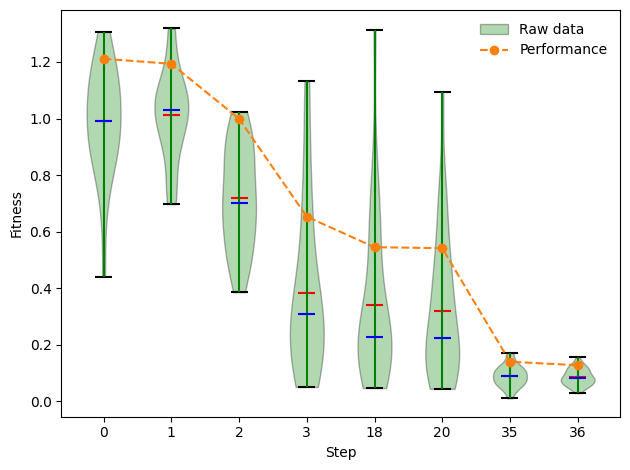

In [118]:
from customhys import visualisation as vis
vis.show_performance_overview(steps, historical_fitness, performances)

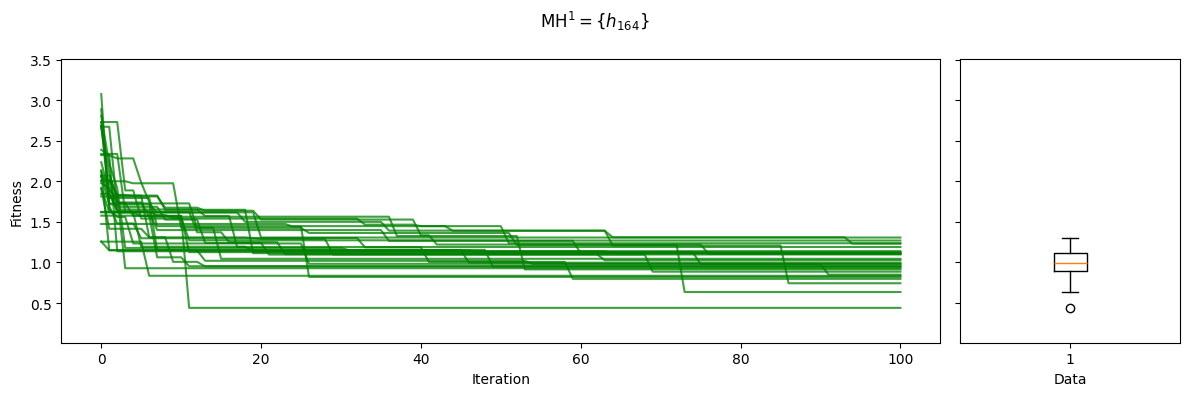

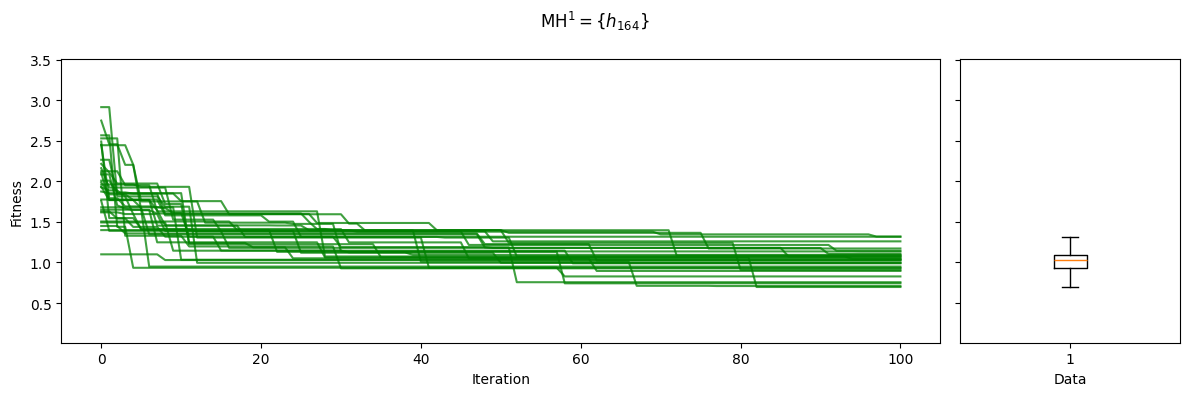

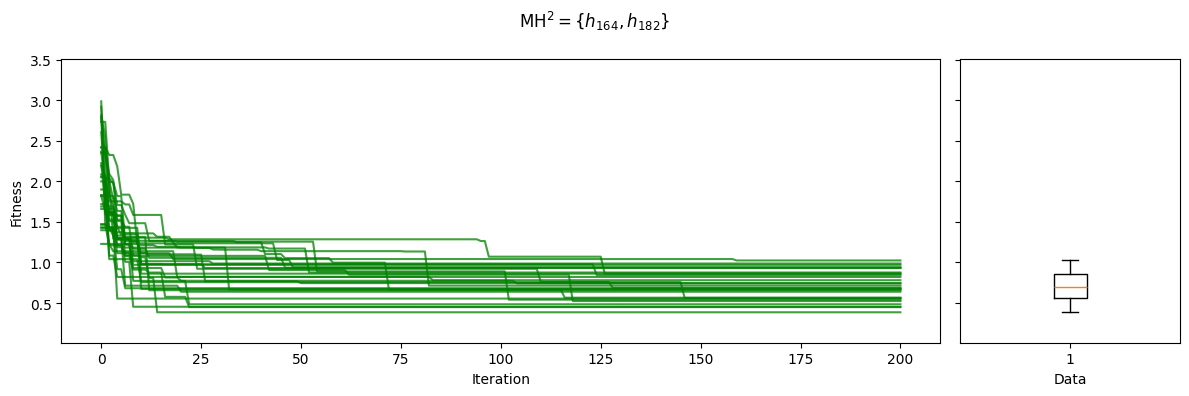

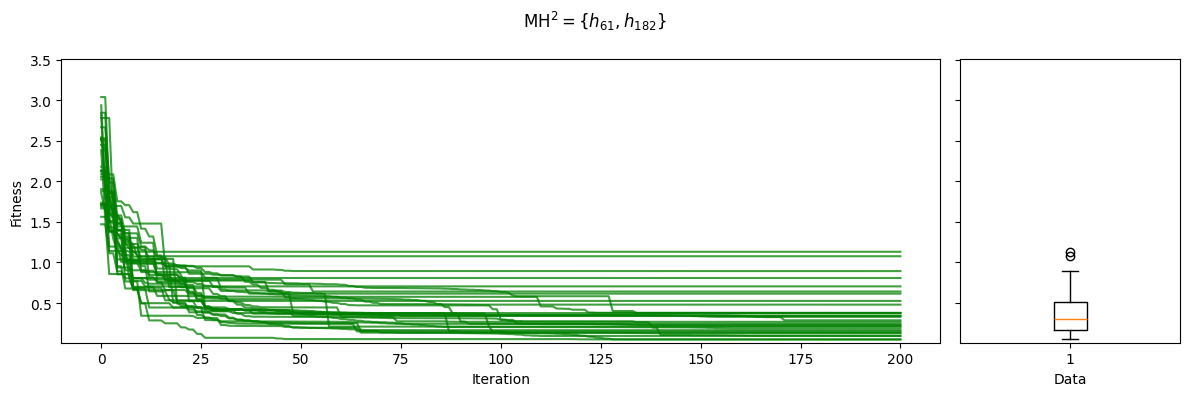

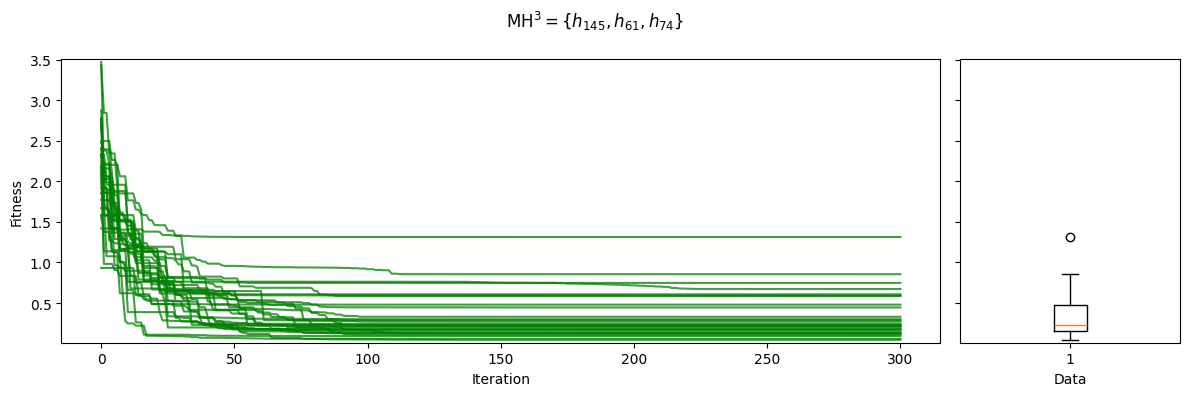

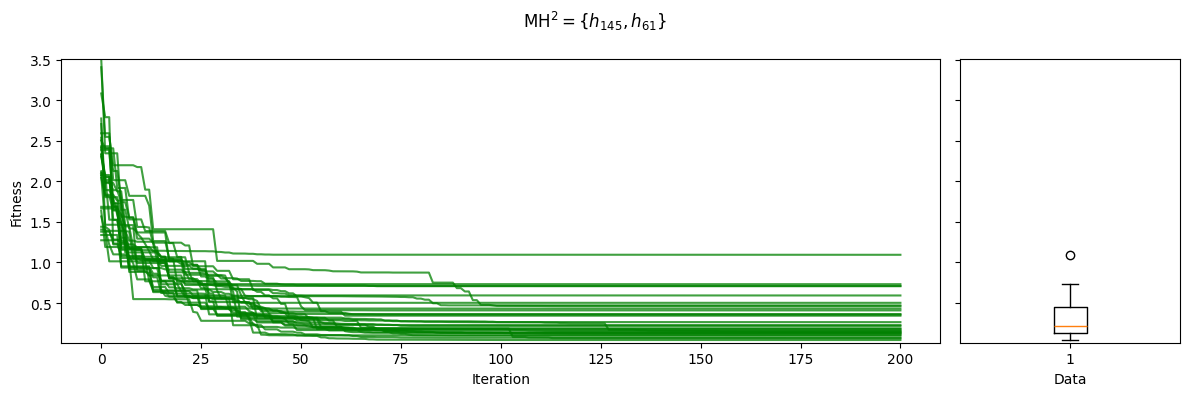

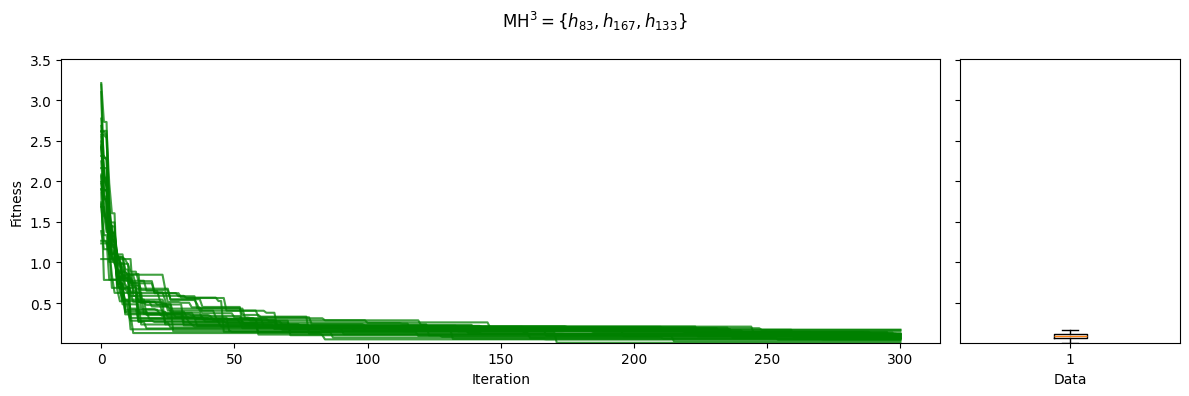

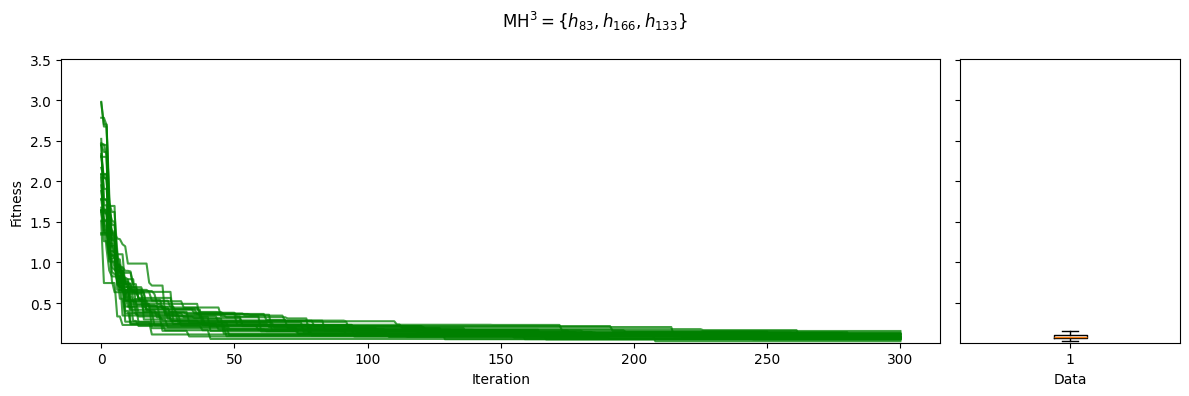

In [119]:
initial_fitness = max([max([x['fitness'][0] for x in fitness_rep['details']['historical']]) for fitness_rep in full_data])
best_fitness = np.min(historical_fitness)

for ii, step in enumerate(steps):
    historical_data = full_data[ii]['details']['historical']
    all_fitness_repetitions = np.array([fitness_rep['fitness'] for fitness_rep in historical_data]).T

    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey='row', gridspec_kw={'width_ratios': [0.8, 0.2]})
    axs[0].plot(all_fitness_repetitions, 'g', alpha=0.75)
    axs[0].set_ylabel(r'Fitness')
    axs[0].set_xlabel(r'Iteration')
    axs[0].set_ylim([best_fitness, initial_fitness])

    axs[1].boxplot(historical_fitness[ii])
    axs[1].set_xlabel(r'Data')

    plt.suptitle(r'MH$^{' + '{}'.format(len(full_data[ii]['encoded_solution'])) + '} = \\{' +
              '}, '.join(['h_{' + str(x) for x in full_data[ii]['encoded_solution']]) + '}\\}$')
    plt.tight_layout()
    plt.show()
    # plt.savefig('hh_raw_fitness_s{}.eps'.format(data['step'][ii]))


In [120]:
met = mh.Metaheuristic(prob, heur, num_iterations=1000)
met.verbose = True
met.run()
print('x_best = {}, f_best = {}'.format(*met.get_solution()))


Search operators to employ:
differential_mutation(expression='current-to-best',num_rands=2,factor=1.0) with greedy
differential_crossover(crossover_rate=0.2,version='binomial') with greedy
--------------------------------------------------
1
pop. radius: 1.6604493007436902
x_best = [ 11.1406679   28.99944779 -10.40009883  22.42614519  21.26996324], f_best = 1.5045995664017182
2
pop. radius: 1.6461487270241442
x_best = [ 11.1406679   28.99944779 -10.40009883  22.42614519  21.26996324], f_best = 1.5045995664017182
3
pop. radius: 1.6461487270241442
x_best = [ 11.1406679   28.99944779 -10.40009883  22.42614519  21.26996324], f_best = 1.5045995664017182
4
pop. radius: 1.6461487270241442
x_best = [ 11.1406679   28.99944779 -10.40009883  22.42614519  21.26996324], f_best = 1.5045995664017182
5
pop. radius: 1.6461487270241442
x_best = [ 11.1406679   28.99944779 -10.40009883  22.42614519  21.26996324], f_best = 1.5045995664017182
6
pop. radius: 1.642619034744537
x_best = [ 11.1406679   28.9994

In [121]:
hist_values = met.historical
tl.printmsk(hist_values)

|-- {dict: 4}
|  |-- fitness = {list: 2001}
|  |  |-- 0 = {ndarray: }
:  :  :  
|  |-- position = {list: 2001}
|  |  |-- 0 = {ndarray: 5}
:  :  :  
|  |-- centroid = {list: 2001}
|  |  |-- 0 = {ndarray: 5}
:  :  :  
|  |-- radius = {list: 2001}
|  |  |-- 0 = {float64}
:  :  :  


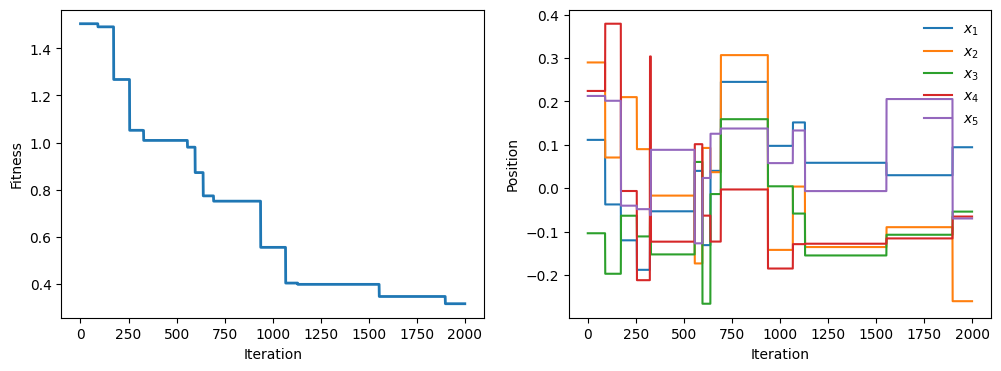

In [122]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(hist_values['fitness'], lw=2)
axs[0].set_xlabel('Iteration'), axs[0].set_ylabel('Fitness')

axs[1].plot(hist_values['position'])
# axs[1].plot(hist_values['radius'])
axs[1].set_xlabel(r'Iteration'), axs[1].set_ylabel(r'Position')
axs[1].legend([f"$x_{ii+1}$" for ii in range(6)], frameon=False)

plt.show()

### 5.1 Using CEC2005 functions
To use them we need to install the package `optproblems`

In [123]:
#!pip install optproblems

In [124]:
from customhys import benchmark_func as bf

In [125]:
problem = bf.CEC2005("F4", 5)

In [126]:
met = mh.Metaheuristic(problem.get_formatted_problem(), heur, num_iterations=1000)
met.verbose = True
met.run()
print('x_best = {}, f_best = {}'.format(*met.get_solution()))


Search operators to employ:
differential_mutation(expression='current-to-best',num_rands=2,factor=1.0) with greedy
differential_crossover(crossover_rate=0.2,version='binomial') with greedy
--------------------------------------------------
1
pop. radius: 2.1278724820046606
x_best = [  42.95925934  -52.91661774 -100.            0.27230369   47.19593276], f_best = 4873.284963609604
2
pop. radius: 2.1241804340662154
x_best = [  42.95925934  -52.91661774 -100.            0.27230369   47.19593276], f_best = 4873.284963609604
3
pop. radius: 2.0735085626355634
x_best = [  42.95925934  -52.91661774 -100.            0.27230369   47.19593276], f_best = 4873.284963609604
4
pop. radius: 2.094456808077411
x_best = [ 29.29605971 -95.89895733 -35.55996097 -47.5854705  100.        ], f_best = 2753.4686182704477
5
pop. radius: 2.1098961536285863
x_best = [  31.20929068  -82.48862881    9.94421604 -100.          100.        ], f_best = 423.4904014370478
6
pop. radius: 2.230567217252177
x_best = [  31.2

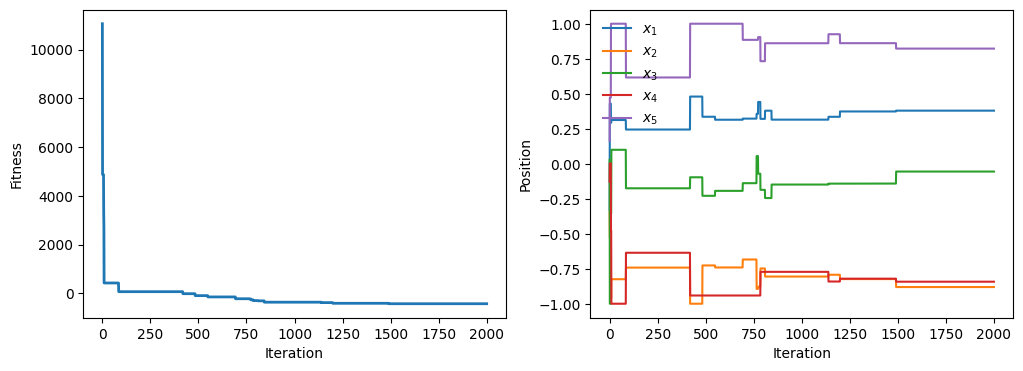

In [127]:
hist_values = met.historical
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(hist_values['fitness'], lw=2)
axs[0].set_xlabel('Iteration'), axs[0].set_ylabel('Fitness')

axs[1].plot(hist_values['position'])
# axs[1].plot(hist_values['radius'])
axs[1].set_xlabel(r'Iteration'), axs[1].set_ylabel(r'Position')
axs[1].legend([f"$x_{ii+1}$" for ii in range(6)], frameon=False)

plt.show()

In [128]:
dime = 20
fun = bf.CEC2005("F4", dime)

cate = fun.get_features()
prob = fun.get_formatted_problem()

hyp = hh.Hyperheuristic(heuristic_space="default.txt",
                        problem=prob, parameters=parameters, file_label='CEC-F4-20D-Exp2')

best_sol, best_perf, hist_curr, hist_best = hyp.solve()

CEC-F4-20D-Exp2 :: Step:    0, Action: None        , Temp: 1.00e+02, Card:   1, Perf: 8.13e+04 [Initial]
CEC-F4-20D-Exp2 :: Step:    1, Action: RollMany    , Temp: 1.00e+02, Card:   1, candPerf: 6.69e+04, currPerf: 8.13e+04, bestPerf: 8.13e+04 , [Delta: -1.44e+04, ArgProb: 1.77e-03, Prob: 1.00] A+
CEC-F4-20D-Exp2 :: Step:    2, Action: LocalShift  , Temp: 5.00e+01, Card:   1, candPerf: 7.14e+04, currPerf: 6.69e+04, bestPerf: 6.69e+04 , [Delta: 4.51e+03, ArgProb: -1.11e-03, Prob: 1.00] A
CEC-F4-20D-Exp2 :: Step:    3, Action: Add         , Temp: 3.33e+01, Card:   2, candPerf: 5.15e+04, currPerf: 7.14e+04, bestPerf: 6.69e+04 , [Delta: -1.99e+04, ArgProb: 7.34e-03, Prob: 1.00] A+
CEC-F4-20D-Exp2 :: Step:    4, Action: LocalShift  , Temp: 2.50e+01, Card:   2, candPerf: 5.48e+04, currPerf: 5.15e+04, bestPerf: 5.15e+04 , [Delta: 3.24e+03, ArgProb: -1.60e-03, Prob: 1.00] A
CEC-F4-20D-Exp2 :: Step:    5, Action: Shift       , Temp: 2.00e+01, Card:   2, candPerf: 4.83e+04, currPerf: 5.48e+04, b

/Users/jcrvz/PycharmProjects/customhys/customhys/population.py:235: RuntimeWarning: invalid value encountered in cast
  self.velocities[agent_id, :] = np.copy(self.previous_velocities[agent_id, :])


CEC-F4-20D-Exp2 :: Step:   21, Action: Restart     , Temp: 4.76e+00, Card:   3, candPerf: 9.09e+04, currPerf: 5.86e+04, bestPerf: 2.10e+04 , [Delta: 3.22e+04, ArgProb: -8.33e-02, Prob: 0.92] A
CEC-F4-20D-Exp2 :: Step:   22, Action: Shift       , Temp: 4.55e+00, Card:   3, candPerf: 1.05e+05, currPerf: 9.09e+04, bestPerf: 2.10e+04 , [Delta: 1.37e+04, ArgProb: -3.72e-02, Prob: 0.96] A
CEC-F4-20D-Exp2 :: Step:   23, Action: Shift       , Temp: 4.35e+00, Card:   3, candPerf: 8.07e+04, currPerf: 1.05e+05, bestPerf: 2.10e+04 , [Delta: -2.39e+04, ArgProb: 6.76e-02, Prob: 1.00] A
CEC-F4-20D-Exp2 :: Step:   24, Action: Mirror      , Temp: 4.17e+00, Card:   3, candPerf: 8.29e+04, currPerf: 8.07e+04, bestPerf: 2.10e+04 , [Delta: 2.23e+03, ArgProb: -6.60e-03, Prob: 0.99] A
CEC-F4-20D-Exp2 :: Step:   25, Action: Shift       , Temp: 4.00e+00, Card:   3, candPerf: 5.82e+04, currPerf: 8.29e+04, bestPerf: 2.10e+04 , [Delta: -2.48e+04, ArgProb: 7.62e-02, Prob: 1.00] A
CEC-F4-20D-Exp2 :: Step:   26, Acti

In [129]:
full_data = tl.merge_json("./data_files/raw/CEC-F4-20D-Exp2")

100%|██████████| 8/8 [00:00<00:00, 12.83it/s]


Merged file saved: ./data_files/raw/CEC-F4-20D-Exp2.json


In [130]:
full_data = tl.read_json("./data_files/raw/CEC-F4-20D-Exp2.json")

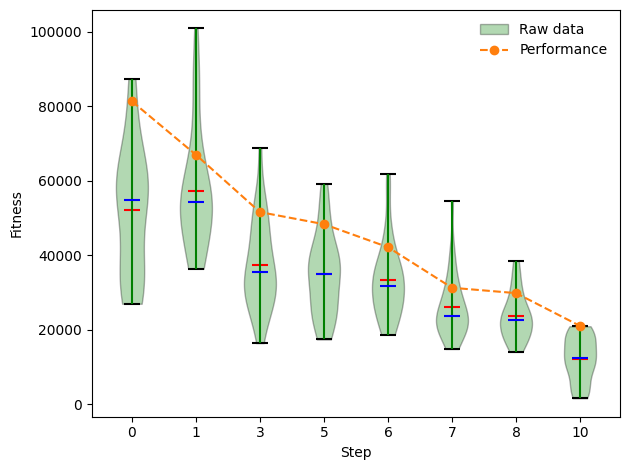

In [131]:
num_steps = len(full_data)
# print(full_data['details'])
# historical_fitness = [[x[['fitness']][-1] for x in historical] for historical in full_data['details']]
historical_fitness = [x['details']['fitness'] for x in full_data]
performances = [x['performance'] for x in full_data]
steps = [x['step'] for x in full_data]

vis.show_performance_overview(steps, historical_fitness, performances)

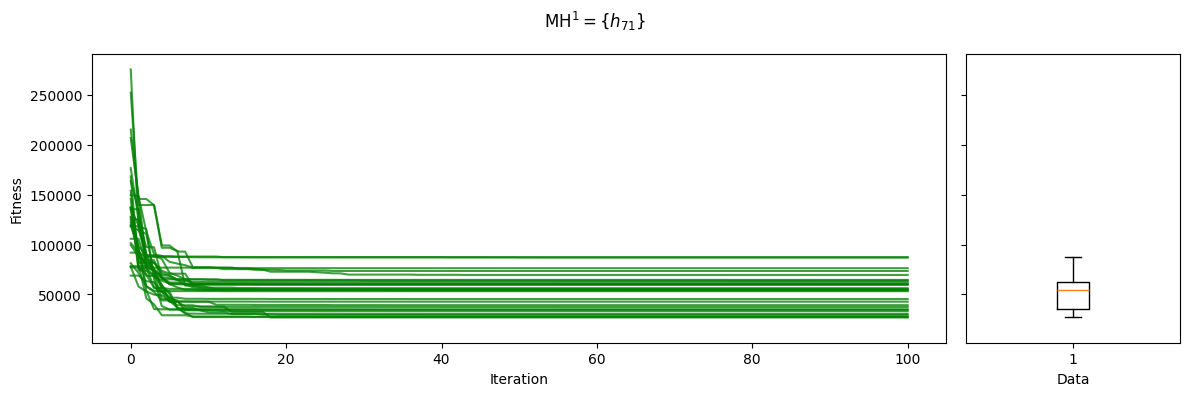

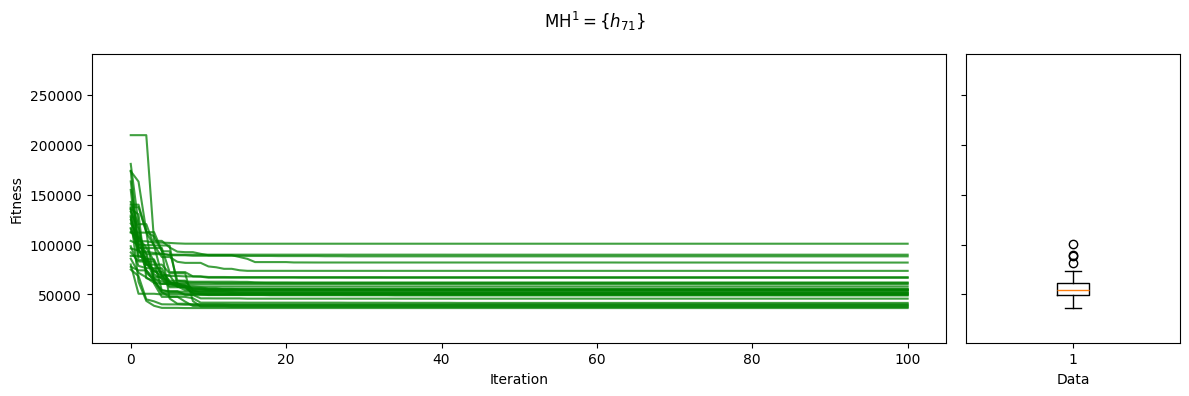

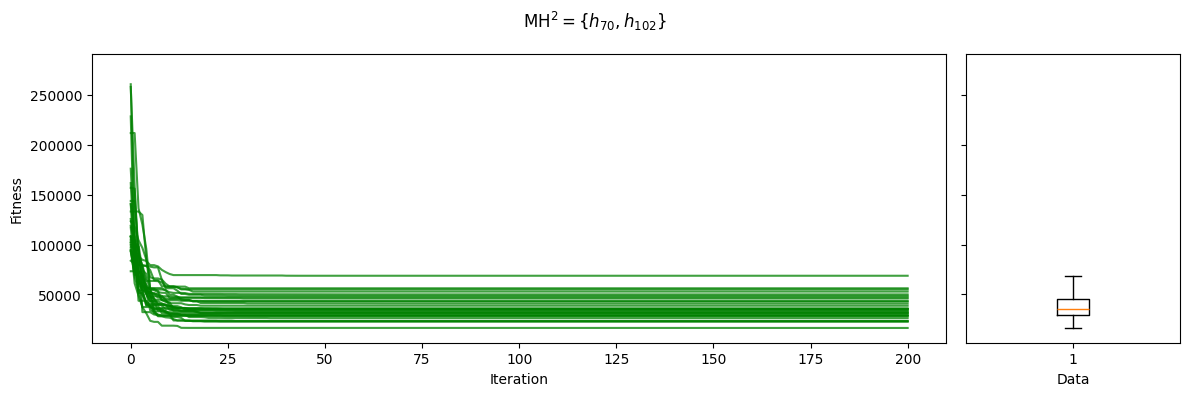

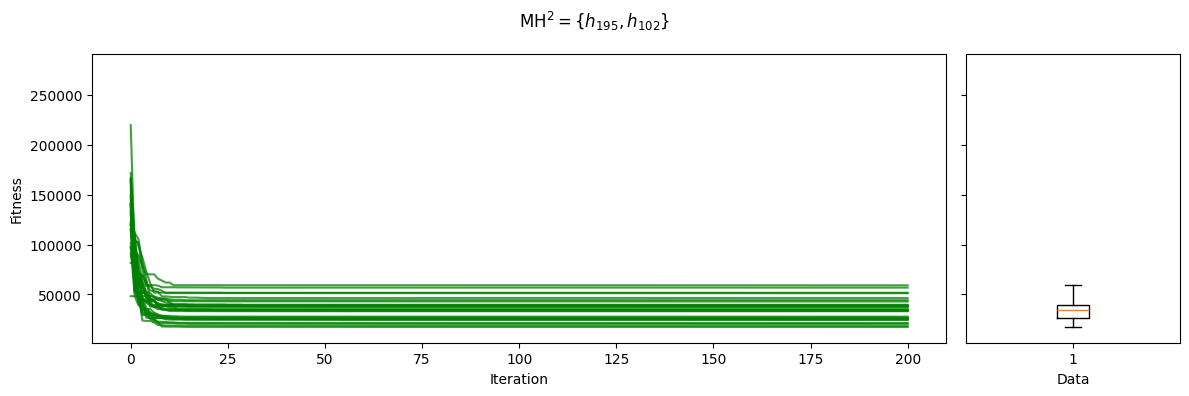

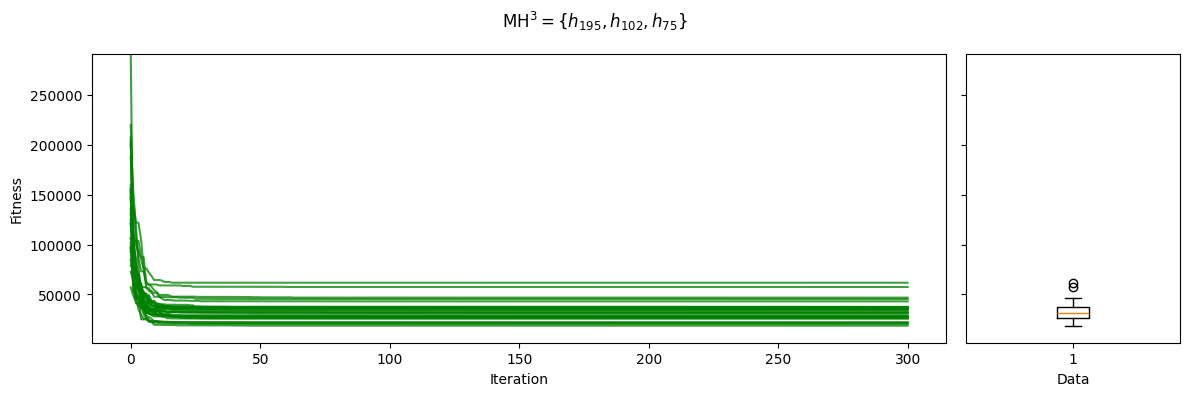

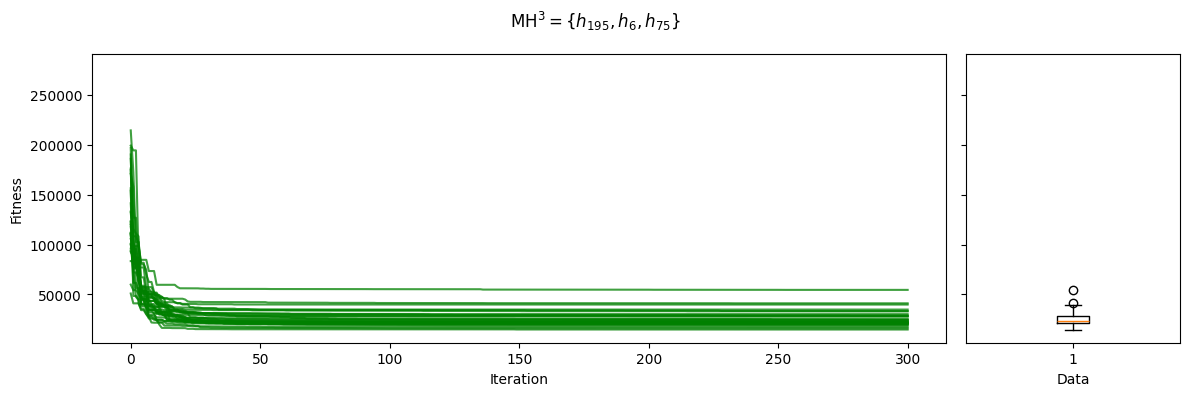

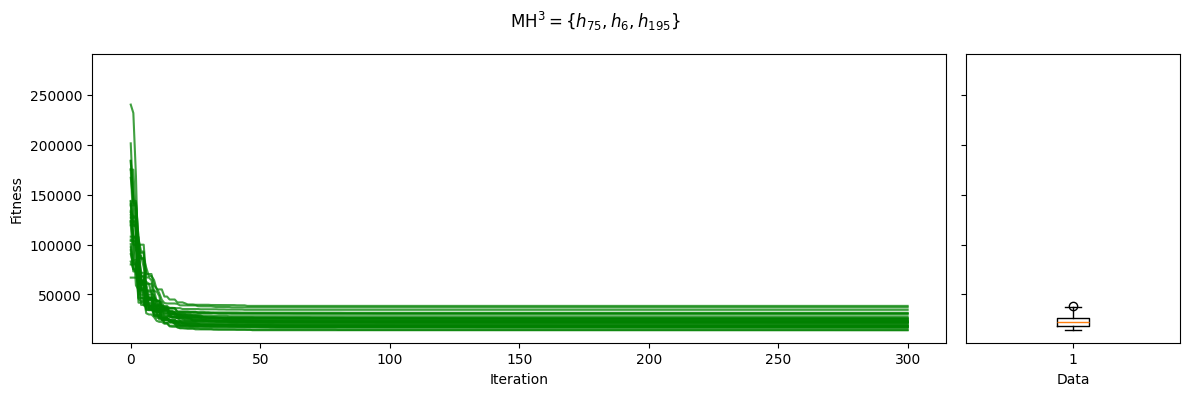

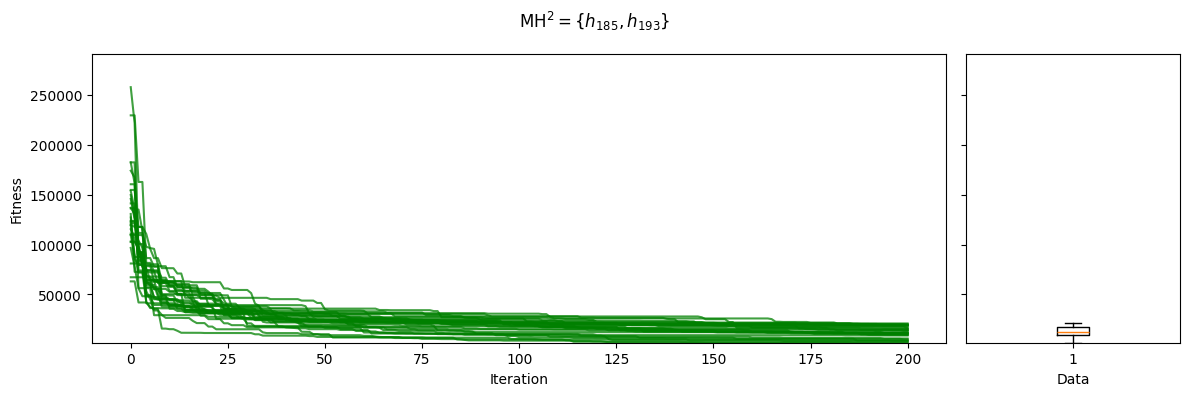

In [132]:
initial_fitness = max([max([x['fitness'][0] for x in fitness_rep['details']['historical']]) for fitness_rep in full_data])
best_fitness = np.min(historical_fitness)

for ii, step in enumerate(steps):
    historical_data = full_data[ii]['details']['historical']
    all_fitness_repetitions = np.array([fitness_rep['fitness'] for fitness_rep in historical_data]).T

    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharey='row', gridspec_kw={'width_ratios': [0.8, 0.2]})
    axs[0].plot(all_fitness_repetitions, 'g', alpha=0.75)
    axs[0].set_ylabel(r'Fitness')
    axs[0].set_xlabel(r'Iteration')
    axs[0].set_ylim([best_fitness, initial_fitness])

    axs[1].boxplot(historical_fitness[ii])
    axs[1].set_xlabel(r'Data')

    plt.suptitle(r'MH$^{' + '{}'.format(len(full_data[ii]['encoded_solution'])) + '} = \\{' +
              '}, '.join(['h_{' + str(x) for x in full_data[ii]['encoded_solution']]) + '}\\}$')
    plt.tight_layout()
    plt.show()
    # plt.savefig('hh_raw_fitness_s{}.eps'.format(data['step'][ii]))
